# Maxilla Sex Classification — Full Pipeline
**Two-Framework Study:**
- Framework 1: Feature Selection → Hyperparameter Tuning
- Framework 2: Hyperparameter Tuning → Feature Selection

Datasets: Combined (All), Assiut, Benha — each with its own stratified 80-20 split (same seed).

## 1. Required Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json

from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, train_test_split
)
from sklearn.metrics import (
    roc_auc_score, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import RFE, SelectKBest, f_classif
from sklearn.base import clone

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')

# ── Global reproducibility seed ──
SEED = 42

## 2. Load Data

In [2]:
df = pd.read_excel("data/New data.xlsx")

df = df.rename(columns={
    "sex (F=0, M=1)": "Sex",
    "age (years)": "Age",
    "Rt. Max. AP (cm) Right Maxilla Anteroposterior Diameter (cm)": "Rt_Max_AP",
    "Rt. Max. TR (cm) Right Maxilla Transverse Diameter (cm)": "Rt_Max_TR",
    "Rt. Max. CC (cm) Right Maxilla Craniocaudal Diameter (cm)": "Rt_Max_CC",
    "Lt. Max. AP (cm)  Left Maxilla Anteroposterior Diameter (cm": "Lt_Max_AP",
    "Lt. Max. TR (cm) Left Maxilla Transverse Diameter (cm": "Lt_Max_TR",
    "Lt. Max. CC (cm)  Left Maxilla Craniocaudal Diameter (cm)": "Lt_Max_CC",
    "Nfa (nasofrontal angle)": "NFa",
    "Pa (pyramidal angle)": "Pa",
    "NT nasion tip distance": "NT"
})

print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(df.head(3))

Loaded: 195 rows × 13 columns
  Subject  Age Sex regionn  Rt_Max_AP  Rt_Max_TR  Rt_Max_CC  Lt_Max_AP  \
0      S1   19   F  Assiut       3.63       2.19       3.46       3.54   
1      S5   24   F  Assiut       3.60       2.55       3.15       3.44   
2      S7   24   M  Assiut       3.60       2.66       3.46       3.43   

   Lt_Max_TR  Lt_Max_CC     NFa     Pa    NT  
0       1.94       3.49  122.83  55.17  2.49  
1       2.13       3.19  119.06  56.46  2.06  
2       2.68       3.57  125.30  58.23  2.76  


## 3. Feature Engineering

In [3]:
def safe_ratio(a, b):
    """Division guarded against zero denominator → NaN."""
    return np.where(b != 0, a / b, np.nan)

def asymmetry(a, b):
    """Bilateral asymmetry index: |a-b| / mean(a,b)."""
    return np.abs(a - b) / ((a + b) / 2)

# --- Ratios ---
df["Rt_AP_TR"] = safe_ratio(df["Rt_Max_AP"], df["Rt_Max_TR"])
df["Lt_AP_TR"] = safe_ratio(df["Lt_Max_AP"], df["Lt_Max_TR"])
df["Rt_TR_CC"] = safe_ratio(df["Rt_Max_TR"], df["Rt_Max_CC"])
df["Lt_TR_CC"] = safe_ratio(df["Lt_Max_TR"], df["Lt_Max_CC"])

# --- Asymmetry (Right vs Left) ---
df["AP_asym"] = asymmetry(df["Rt_Max_AP"], df["Lt_Max_AP"])
df["TR_asym"] = asymmetry(df["Rt_Max_TR"], df["Lt_Max_TR"])
df["CC_asym"] = asymmetry(df["Rt_Max_CC"], df["Lt_Max_CC"])

# --- Bilateral means ---
df["AP_mean"] = (df["Rt_Max_AP"] + df["Lt_Max_AP"]) / 2
df["TR_mean"] = (df["Rt_Max_TR"] + df["Lt_Max_TR"]) / 2
df["CC_mean"] = (df["Rt_Max_CC"] + df["Lt_Max_CC"]) / 2

# --- Clean inf / NaN ---
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

# ── Feature lists ──
raw_features = [
    "Rt_Max_AP", "Lt_Max_AP",
    "Rt_Max_TR", "Lt_Max_TR",
    "Rt_Max_CC", "Lt_Max_CC",
    "NFa", "Pa", "NT", "Age"
]
engineered_features = [
    "Rt_AP_TR", "Lt_AP_TR",
    "Rt_TR_CC", "Lt_TR_CC",
    "AP_asym", "TR_asym", "CC_asym",
    "AP_mean", "TR_mean", "CC_mean"
]
all_features = raw_features + engineered_features  # 20 features — FS starting pool

y = df["Sex"].map({"F": 0, "M": 1}).astype(int)

print(f"Total samples: {len(y)} | Features: {len(all_features)}")
print(f"Class balance: Male={y.sum()} ({y.mean()*100:.1f}%) | Female={len(y)-y.sum()}")

Total samples: 195 | Features: 20
Class balance: Male=95 (48.7%) | Female=100


## 4. Train-Test Split (80-20, Stratified)
Three datasets — Combined, Assiut, Benha — each split independently with the same seed so results are comparable.

In [4]:
assiut_mask = df["regionn"] == "Assiut"
benha_mask  = df["regionn"] == "Benha"

datasets = {}

assert df[all_features].isnull().sum().sum() == 0, \
    "Unexpected NaNs found in features — check data source"

for name, mask in [("All", pd.Series([True]*len(df))),
                   ("Assiut", assiut_mask),
                   ("Benha", benha_mask)]:
    X_sub = df.loc[mask, all_features].copy().reset_index(drop=True)
    y_sub = y[mask].reset_index(drop=True)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_sub, y_sub,
        test_size=0.2,
        stratify=y_sub,
        random_state=SEED
    )
    X_tr = X_tr.reset_index(drop=True)
    X_te = X_te.reset_index(drop=True)
    y_tr = y_tr.reset_index(drop=True)
    y_te = y_te.reset_index(drop=True)

    datasets[name] = dict(X_train=X_tr, X_test=X_te, y_train=y_tr, y_test=y_te)
    print(f"{name:8s}: train={len(y_tr):3d} "
          f"(M={y_tr.sum()}, F={len(y_tr)-y_tr.sum()}) | "
          f"test={len(y_te):3d} "
          f"(M={y_te.sum()}, F={len(y_te)-y_te.sum()})")

# Shared CV — applied strictly on train sets only
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

All     : train=156 (M=76, F=80) | test= 39 (M=19, F=20)
Assiut  : train= 83 (M=41, F=42) | test= 21 (M=10, F=11)
Benha   : train= 72 (M=35, F=37) | test= 19 (M=9, F=10)


## 5. Shared Utilities
Model factory, CV evaluation, metrics computation — defined once, used by both scenarios.

In [5]:
# ============================================================
# 5.1  Model factory — builds a fresh model from a name + params dict
# ============================================================

def build_model(model_name, params=None):
    """Return a fresh (un-fitted) model. params override defaults."""
    p = params or {}
    if model_name == "CatBoost":
        defaults = dict(iterations=200, depth=4, learning_rate=0.05,
                        l2_leaf_reg=3, random_state=SEED, verbose=0)
        defaults.update(p)
        return CatBoostClassifier(**defaults)

    elif model_name == "XGBoost":
        defaults = dict(n_estimators=200, max_depth=4, learning_rate=0.05,
                        random_state=SEED, eval_metric="auc", verbosity=0)
        defaults.update(p)
        return XGBClassifier(**defaults)

    elif model_name == "LightGBM":
        defaults = dict(n_estimators=200, max_depth=4, learning_rate=0.05,
                        random_state=SEED, verbosity=-1)
        defaults.update(p)
        return LGBMClassifier(**defaults)

    elif model_name == "RandomForest":
        defaults = dict(n_estimators=200, max_depth=6, random_state=SEED)
        defaults.update(p)
        return RandomForestClassifier(**defaults)

    elif model_name == "LR":
        lr_p = {k: v for k, v in p.items() if k in ("C",)}
        defaults = dict(C=1.0, solver="liblinear", penalty="l2")
        defaults.update(lr_p)
        return Pipeline([("scaler", StandardScaler()),
                         ("clf", LogisticRegression(**defaults))])

    elif model_name == "SVM":
        svm_p = {k: v for k, v in p.items() if k in ("C", "gamma")}
        defaults = dict(C=1.0, gamma="scale", kernel="rbf", probability=True)
        defaults.update(svm_p)
        return Pipeline([("scaler", StandardScaler()),
                         ("clf", SVC(**defaults))])

    else:
        raise ValueError(f"Unknown model: {model_name}")


MODEL_NAMES = ["CatBoost", "XGBoost", "LightGBM", "RandomForest", "LR", "SVM"]


# ============================================================
# 5.2  Specificity helper
# ============================================================

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else np.nan


# ============================================================
# 5.2b  Bootstrap 95% CI for test-set metrics
#       Resamples the held-out test set (with replacement) since
#       only a single train/test split exists per combination.
# ============================================================

def bootstrap_test_ci(y_true, y_prob, y_pred, n_boot=1000, ci=0.95, seed=SEED):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    rng = np.random.RandomState(seed)

    boot = {"accuracy": [], "auc": [], "sensitivity": [], "specificity": [], "f1": []}
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        yt, yp, ypr = y_true[idx], y_pred[idx], y_prob[idx]
        if len(np.unique(yt)) < 2:
            continue
        boot["accuracy"].append(accuracy_score(yt, yp))
        boot["auc"].append(roc_auc_score(yt, ypr))
        boot["sensitivity"].append(recall_score(yt, yp, zero_division=0))
        boot["specificity"].append(specificity_score(yt, yp))
        boot["f1"].append(f1_score(yt, yp, zero_division=0))

    alpha = (1 - ci) / 2
    result = {}
    for metric, values in boot.items():
        if len(values) == 0:
            result[metric] = (float("nan"), float("nan"))
        else:
            lo, hi = np.percentile(values, [100 * alpha, 100 * (1 - alpha)])
            result[metric] = (round(float(lo), 4), round(float(hi), 4))
    return result


# ============================================================
# 5.3  Full per-fold evaluation → mean ± std + final test score
# ============================================================

def evaluate_model_cv(model_name, X_train, y_train, X_test, y_test,
                      cv, params=None, feature_subset=None):
    """
    Run 5-fold CV on train set, then evaluate on held-out test set.
    Returns a dict with mean±std per metric and final test scores.

    feature_subset: list of column names to use (None = use all columns).
    """
    if feature_subset is not None:
        X_train = X_train[feature_subset]
        X_test  = X_test[feature_subset]

    fold_metrics = {"accuracy": [], "auc": [], "precision": [],
                    "recall": [], "f1": [], "specificity": []}

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr_f = X_train.iloc[train_idx]
        X_va_f = X_train.iloc[val_idx]
        y_tr_f = y_train.iloc[train_idx]
        y_va_f = y_train.iloc[val_idx]

        m = clone(build_model(model_name, params))
        m.fit(X_tr_f, y_tr_f)
        y_pred = m.predict(X_va_f)
        y_prob = m.predict_proba(X_va_f)[:, 1]

        fold_metrics["accuracy"].append(accuracy_score(y_va_f, y_pred))
        fold_metrics["auc"].append(roc_auc_score(y_va_f, y_prob))
        fold_metrics["precision"].append(precision_score(y_va_f, y_pred, zero_division=0))
        fold_metrics["recall"].append(recall_score(y_va_f, y_pred, zero_division=0))
        fold_metrics["f1"].append(f1_score(y_va_f, y_pred, zero_division=0))
        fold_metrics["specificity"].append(specificity_score(y_va_f, y_pred))

    # Train final model on full train set, evaluate on test
    final_model = clone(build_model(model_name, params))
    final_model.fit(X_train, y_train)
    y_pred_test = final_model.predict(X_test)
    y_prob_test = final_model.predict_proba(X_test)[:, 1]

    result = {}
    for metric, values in fold_metrics.items():
        result[f"cv_{metric}_mean"] = np.mean(values)
        result[f"cv_{metric}_std"]  = np.std(values)

    result["test_accuracy"]    = accuracy_score(y_test, y_pred_test)
    result["test_auc"]         = roc_auc_score(y_test, y_prob_test)
    result["test_precision"]   = precision_score(y_test, y_pred_test, zero_division=0)
    result["test_recall"]      = recall_score(y_test, y_pred_test, zero_division=0)
    result["test_f1"]          = f1_score(y_test, y_pred_test, zero_division=0)
    result["test_specificity"] = specificity_score(y_test, y_pred_test)
    result["n_features"]       = X_train.shape[1]
    result["features_used"]    = list(X_train.columns)

    # Bootstrap 95% CI on the held-out test set
    test_ci = bootstrap_test_ci(y_test, y_prob_test, y_pred_test)
    result["test_auc_ci"]         = test_ci["auc"]
    result["test_accuracy_ci"]    = test_ci["accuracy"]
    result["test_sensitivity_ci"] = test_ci["sensitivity"]
    result["test_specificity_ci"] = test_ci["specificity"]
    result["test_f1_ci"]          = test_ci["f1"]

    return result, final_model


# ============================================================
# 5.4  CV-AUC helper (used by FS wrappers — returns scalar)
# ============================================================

def cv_auc_score(model_name, X, y, cv, params=None):
    """Mean AUC across CV folds on a given X, y. Used during FS."""
    scores = []
    for train_idx, val_idx in cv.split(X, y):
        m = clone(build_model(model_name, params))
        m.fit(X.iloc[train_idx], y.iloc[train_idx])
        y_prob = m.predict_proba(X.iloc[val_idx])[:, 1]
        scores.append(roc_auc_score(y.iloc[val_idx], y_prob))
    return np.mean(scores)


print("Utilities defined ✅")

Utilities defined ✅


## 6. Feature Selection Methods
All 5 methods operate **only on the train set**. Each returns a list of selected feature names.

In [6]:
# ============================================================
# 6.1  Backward Elimination
# ============================================================

def backward_selection(X_train, y_train, cv, model_name, params=None,
                        min_features=4, patience=4):
    remaining = list(X_train.columns)
    best_auc  = cv_auc_score(model_name, X_train[remaining], y_train, cv, params)
    best_features = remaining.copy()
    no_improve = 0

    print(f"  [BW|{model_name}] Start AUC ({len(remaining)} features): {best_auc:.4f}")

    while len(remaining) > min_features:
        results = []
        for feat in remaining:
            subset = [f for f in remaining if f != feat]
            auc = cv_auc_score(model_name, X_train[subset], y_train, cv, params)
            results.append((feat, auc))

        results.sort(key=lambda x: x[1], reverse=True)
        feat_to_remove, auc_without = results[0]

        if auc_without > best_auc:
            best_auc = auc_without
            best_features = [f for f in remaining if f != feat_to_remove]
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            break

        remaining.remove(feat_to_remove)

    print(f"  [BW|{model_name}] Best: {len(best_features)} features | AUC: {best_auc:.4f}")
    return best_features


# ============================================================
# 6.2  Forward Selection
# ============================================================

def forward_selection(X_train, y_train, cv, model_name, params=None,
                       min_improvement=0.0001, patience=4):
    remaining   = list(X_train.columns)
    selected    = []
    best_auc    = 0.0
    no_improve  = 0

    while remaining:
        results = []
        for feat in remaining:
            subset = selected + [feat]
            auc = cv_auc_score(model_name, X_train[subset], y_train, cv, params)
            results.append((feat, auc))

        results.sort(key=lambda x: x[1], reverse=True)
        best_feat, best_candidate_auc = results[0]

        if best_candidate_auc - best_auc > min_improvement:
            selected.append(best_feat)
            remaining.remove(best_feat)
            best_auc = best_candidate_auc
            no_improve = 0
        else:
            no_improve += 1
            remaining.remove(best_feat)  # skip this feature, try others
            if no_improve >= patience:
                break

    print(f"  [FW|{model_name}] Best: {len(selected)} features | AUC: {best_auc:.4f}")
    return selected if selected else list(X_train.columns[:1])


# ============================================================
# 6.3  RFE — Recursive Feature Elimination
#      Uses a LinearSVC-compatible estimator internally (fast),
#      then evaluates the selected subset with the target model.
# ============================================================

def rfe_selection(X_train, y_train, cv, model_name, params=None, n_features_to_select=None):
    """
    RFE with internal LogisticRegression ranker (stable feature importance).
    Tries n_features from 1..n and picks the subset with best CV-AUC.
    """
    n_total = X_train.shape[1]
    if n_features_to_select is not None:
        # Fixed k
        ranker = Pipeline([("scaler", StandardScaler()),
                           ("clf", LogisticRegression(solver="liblinear", max_iter=1000))])
        rfe = RFE(estimator=ranker, n_features_to_select=n_features_to_select, step=1)
        rfe.fit(X_train, y_train)
        return list(X_train.columns[rfe.support_])

    # Auto-select: try each possible k and pick best CV-AUC
    best_auc      = -1
    best_features = list(X_train.columns)

    for k in range(2, n_total + 1):

        # Use Random Forest purely to select the features, regardless of `model_name`
        rfe_estimator = RandomForestClassifier(n_estimators=50, random_state=42)
    
        rfe = RFE(estimator=rfe_estimator, n_features_to_select=k, step=1)
        rfe.fit(X_train, y_train)
    
        subset = list(X_train.columns[rfe.support_])
        auc = cv_auc_score(model_name, X_train[subset], y_train, cv, params)    
        if auc > best_auc:
            best_auc = auc
            best_features = subset

    print(f"  [RFE|{model_name}] Best: {len(best_features)} features | AUC: {best_auc:.4f}")
    return best_features


# ============================================================
# 6.4  SelectKBest (ANOVA F-statistic filter)
#      Sweeps k, picks best CV-AUC with target model.
# ============================================================

def selectkbest_selection(X_train, y_train, cv, model_name, params=None):
    n_total   = X_train.shape[1]
    best_auc  = -1
    best_features = list(X_train.columns)

    for k in range(2, n_total + 1):
        selector = SelectKBest(score_func=f_classif, k=k)
        selector.fit(X_train, y_train)
        subset = list(X_train.columns[selector.get_support()])
        auc = cv_auc_score(model_name, X_train[subset], y_train, cv, params)
        if auc > best_auc:
            best_auc = auc
            best_features = subset

    print(f"  [SKB|{model_name}] Best: {len(best_features)} features | AUC: {best_auc:.4f}")
    return best_features


# ============================================================
# 6.5  LASSO-based selection (L1 Logistic — proper classifier)
#      LogisticRegressionCV with L1 penalty selects features
#      whose coefficients are non-zero at the best regularisation C.
#      Falls back to top-5 by |coeff| if all are zeroed out.
# ============================================================

def lasso_selection(X_train, y_train, cv, model_name, params=None):
    from sklearn.linear_model import LogisticRegressionCV
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

    lasso = LogisticRegressionCV(
        penalty="l1", solver="liblinear",
        cv=5, random_state=SEED, max_iter=5000
    )
    lasso.fit(X_scaled, y_train)

    mask = lasso.coef_[0] != 0
    if mask.sum() == 0:
        # Fallback: take top-5 by absolute coefficient magnitude
        top_idx = np.argsort(np.abs(lasso.coef_[0]))[::-1][:5]
        mask = np.zeros(len(lasso.coef_[0]), dtype=bool)
        mask[top_idx] = True
        print(f"  [LASSO|{model_name}] All coefficients zero — using top-5 fallback")

    selected = list(X_train.columns[mask])
    auc = cv_auc_score(model_name, X_train[selected], y_train, cv, params)
    print(f"  [LASSO|{model_name}] Best: {len(selected)} features | AUC: {auc:.4f}")
    return selected


# ── Dispatcher ──
FS_METHODS = {
    "Backward":    backward_selection,
    "Forward":     forward_selection,
    "RFE":         rfe_selection,
    "SelectKBest": selectkbest_selection,
    "LASSO":       lasso_selection,
}

print("Feature selection methods defined ✅")

Feature selection methods defined ✅


## 7. Optuna Hyperparameter Tuning
Single objective factory used by both scenarios.

In [7]:
N_TRIALS = 25

def make_objective(model_name, X_train, y_train, cv):
    """Optuna objective: CV-AUC on train set for a given model."""

    def objective(trial):
        if model_name == "CatBoost":
            params = dict(
                iterations      = trial.suggest_int("iterations", 100, 500),
                depth           = trial.suggest_int("depth", 3, 8),
                learning_rate   = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                l2_leaf_reg     = trial.suggest_float("l2_leaf_reg", 1, 10),
                random_state    = SEED,
                verbose         = 0,
            )
            scores = []
            for tr_idx, va_idx in cv.split(X_train, y_train):
                m = CatBoostClassifier(**params)
                m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
                prob = m.predict_proba(X_train.iloc[va_idx])[:, 1]
                scores.append(roc_auc_score(y_train.iloc[va_idx], prob))
            return np.mean(scores)

        elif model_name == "XGBoost":
            params = dict(
                n_estimators    = trial.suggest_int("n_estimators", 100, 500),
                max_depth       = trial.suggest_int("max_depth", 3, 8),
                learning_rate   = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                subsample       = trial.suggest_float("subsample", 0.6, 1.0),
                colsample_bytree= trial.suggest_float("colsample_bytree", 0.6, 1.0),
                random_state    = SEED, eval_metric="auc", verbosity=0,
            )
            model = XGBClassifier(**params)

        elif model_name == "LightGBM":
            params = dict(
                n_estimators    = trial.suggest_int("n_estimators", 100, 500),
                max_depth       = trial.suggest_int("max_depth", 3, 8),
                learning_rate   = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                subsample       = trial.suggest_float("subsample", 0.6, 1.0),
                colsample_bytree= trial.suggest_float("colsample_bytree", 0.6, 1.0),
                random_state    = SEED, verbosity=-1,
            )
            model = LGBMClassifier(**params)

        elif model_name == "RandomForest":
            params = dict(
                n_estimators    = trial.suggest_int("n_estimators", 100, 500),
                max_depth       = trial.suggest_int("max_depth", 3, 10),
                min_samples_split = trial.suggest_int("min_samples_split", 2, 10),
                min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 5),
                random_state    = SEED,
            )
            model = RandomForestClassifier(**params)

        elif model_name == "LR":
            params = dict(
                C      = trial.suggest_float("C", 0.01, 10, log=True),
                solver = "liblinear", penalty = "l2",
            )
            model = Pipeline([("scaler", StandardScaler()),
                               ("clf", LogisticRegression(**params))])

        elif model_name == "SVM":
            params = dict(
                C     = trial.suggest_float("C", 0.01, 10, log=True),
                gamma = trial.suggest_float("gamma", 0.001, 1, log=True),
                kernel="rbf", probability=True,
            )
            model = Pipeline([("scaler", StandardScaler()),
                               ("clf", SVC(**params))])
        else:
            raise ValueError(f"Unknown model: {model_name}")

        # sklearn models — shared path
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
        return np.mean(scores)

    return objective


def run_optuna(model_name, X_train, y_train, cv, n_trials=N_TRIALS):
    """Run Optuna study and return best_params dict + best AUC."""
    study = optuna.create_study(direction="maximize",
                                 sampler=TPESampler(seed=SEED))
    study.optimize(make_objective(model_name, X_train, y_train, cv),
                   n_trials=n_trials)
    return study.best_params, study.best_value


print("Optuna utilities defined ✅")

Optuna utilities defined ✅


## 8. Results Saving Utility

In [8]:
# Accumulator — keyed by (scenario, dataset)
ALL_RESULTS = {}  # (scenario_name, dataset_name) → list of row dicts


def record_result(scenario, dataset, fs_method, model_name,
                  selected_features, metrics):
    """Append one result row to the accumulator."""
    key = (scenario, dataset)
    if key not in ALL_RESULTS:
        ALL_RESULTS[key] = []

    row = {
        "Scenario":       scenario,
        "Dataset":        dataset,
        "FS_Method":      fs_method,
        "Model":          model_name,
        "N_Features":     len(selected_features),
        "Features":       ", ".join(selected_features),
    }
    row.update(metrics)
    ALL_RESULTS[key].append(row)


def save_results_to_excel(path="results.xlsx"):
    """Write all accumulated results to Excel — one sheet per (scenario, dataset)."""
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        for (scenario, dataset), rows in ALL_RESULTS.items():
            sheet_name = f"{scenario}_{dataset}"[:31]  # Excel 31-char limit
            df_out = pd.DataFrame(rows)

            # Round numeric columns for readability
            num_cols = df_out.select_dtypes(include="number").columns
            df_out[num_cols] = df_out[num_cols].round(4)

            df_out.to_excel(writer, sheet_name=sheet_name, index=False)
    print(f"Results saved to {path} ✅")



def save_supplementary_excel(path="supplementary_table.xlsx"):
    """
    3-sheet Excel:
      - "Combined"    : 60 combinations (30 S1 + 30 S2) for the combined dataset
      - "Assiut" : best model per scenario applied to Assiut (2 rows)
      - "Benha"  : best model per scenario applied to Benha  (2 rows)
    CV metrics formatted as mean ± std.
    """
    SCENARIO_MAP = {
        "S1_FS_then_Tune": "S1: FS → Tune",
        "S2_Tune_then_FS": "S2: Tune → FS",
    }
    scenario_order = {"S1: FS → Tune": 0, "S2: Tune → FS": 1}

    def build_df(rows):
        if not rows:
            return None
        df = pd.DataFrame(rows)

        def fmt(mean_col, std_col):
            return df[mean_col].map("{:.4f}".format) + " ± " + df[std_col].map("{:.4f}".format)

        out = pd.DataFrame()
        out["Scenario"]          = df["Scenario"].map(SCENARIO_MAP)
        out["FS Method"]         = df["FS_Method"]
        out["Model"]             = df["Model"]
        out["N Features"]        = df["N_Features"]
        out["Selected Features"] = df["Features"]
        out["CV Accuracy"]       = fmt("cv_accuracy_mean",    "cv_accuracy_std")
        out["CV AUC"]            = fmt("cv_auc_mean",         "cv_auc_std")
        out["CV Precision"]      = fmt("cv_precision_mean",   "cv_precision_std")
        out["CV Recall"]         = fmt("cv_recall_mean",      "cv_recall_std")
        out["CV F1"]             = fmt("cv_f1_mean",          "cv_f1_std")
        out["CV Specificity"]    = fmt("cv_specificity_mean", "cv_specificity_std")
        for col, raw in [("Test Accuracy",    "test_accuracy"),
                         ("Test AUC",         "test_auc"),
                         ("Test Precision",   "test_precision"),
                         ("Test Recall",      "test_recall"),
                         ("Test F1",          "test_f1"),
                         ("Test Specificity", "test_specificity")]:
            out[col] = df[raw].round(4)
        out["_s"] = out["Scenario"].map(scenario_order)
        out["_auc"] = df["cv_auc_mean"].values
        out = out.sort_values(["_s", "_auc"], ascending=[True, False])
        return out.drop(columns=["_s", "_auc"]).reset_index(drop=True)

    # ── Sheet 1: All — all 60 combinations ──
    all_rows = []
    for (scenario, dataset), rows in ALL_RESULTS.items():
        if dataset == "Combined":
            all_rows.extend(rows)

    # ── Sheets 2 & 3: Assiut / Benha — winner only (best CV-AUC per scenario) ──
    city_sheets = {}
    for city in ["Assiut", "Benha"]:
        city_rows = []
        for (scenario, dataset), rows in ALL_RESULTS.items():
            if dataset == city:
                # pick the single best row (winner) per scenario
                best = max(rows, key=lambda r: r["cv_auc_mean"])
                city_rows.append(best)
        city_sheets[city] = city_rows

    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        for sheet_name, rows in [("Combined", all_rows),
                                  ("Assiut", city_sheets["Assiut"]),
                                  ("Benha",  city_sheets["Benha"])]:
            df_sheet = build_df(rows)
            if df_sheet is None:
                print(f"  Sheet '{sheet_name}': no data")
                continue
            df_sheet.to_excel(writer, sheet_name=sheet_name, index=False)
            ws = writer.sheets[sheet_name]
            for col_cells in ws.columns:
                max_len = max(len(str(c.value)) if c.value else 0 for c in col_cells)
                ws.column_dimensions[col_cells[0].column_letter].width = min(max_len + 2, 60)
            print(f"  Sheet '{sheet_name}': {len(df_sheet)} rows")

    print(f"Supplementary table saved to {path} (3 sheets) ✅")

def save_cities_excel(path="assiut_benha_best_results.xlsx"):
    """
    Single-sheet Excel for Assiut & Benha best results.
    Shows the winner model per scenario for each city (4 rows total).
    """
    rows = []
    for (scenario, dataset), result_rows in ALL_RESULTS.items():
        if dataset not in ("Assiut", "Benha"):
            continue
        rows.extend(result_rows)

    if not rows:
        print("No city results found — run both scenarios first.")
        return

    df = pd.DataFrame(rows)

    def fmt(mean_col, std_col):
        return df[mean_col].map("{:.4f}".format) + " ± " + df[std_col].map("{:.4f}".format)

    out = pd.DataFrame()
    out["Scenario"]          = df["Scenario"].map({
        "S1_FS_then_Tune": "S1: FS → Tune",
        "S2_Tune_then_FS": "S2: Tune → FS",
    })
    out["Dataset"]           = df["Dataset"]
    out["FS Method"]         = df["FS_Method"]
    out["Model"]             = df["Model"]
    out["N Features"]        = df["N_Features"]
    out["Selected Features"] = df["Features"]

    out["CV Accuracy"]       = fmt("cv_accuracy_mean",    "cv_accuracy_std")
    out["CV AUC"]            = fmt("cv_auc_mean",         "cv_auc_std")
    out["CV Precision"]      = fmt("cv_precision_mean",   "cv_precision_std")
    out["CV Recall"]         = fmt("cv_recall_mean",      "cv_recall_std")
    out["CV F1"]             = fmt("cv_f1_mean",          "cv_f1_std")
    out["CV Specificity"]    = fmt("cv_specificity_mean", "cv_specificity_std")

    for col, raw in [("Test Accuracy",    "test_accuracy"),
                     ("Test AUC",         "test_auc"),
                     ("Test Precision",   "test_precision"),
                     ("Test Recall",      "test_recall"),
                     ("Test F1",          "test_f1"),
                     ("Test Specificity", "test_specificity")]:
        out[col] = df[raw].round(4)

    scenario_order = {"S1: FS → Tune": 0, "S2: Tune → FS": 1}
    city_order     = {"Assiut": 0, "Benha": 1}
    out["_s"] = out["Scenario"].map(scenario_order)
    out["_c"] = out["Dataset"].map(city_order)
    out = out.sort_values(["_s", "_c"]).drop(columns=["_s", "_c"]).reset_index(drop=True)

    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        out.to_excel(writer, sheet_name="Assiut & Benha Best", index=False)
        ws = writer.sheets["Assiut & Benha Best"]
        for col_cells in ws.columns:
            max_len = max(len(str(c.value)) if c.value else 0 for c in col_cells)
            ws.column_dimensions[col_cells[0].column_letter].width = min(max_len + 2, 60)

    print(f"City results saved to {path} ✅")
    print(f"  Rows: {len(out)}  (S1-Assiut, S1-Benha, S2-Assiut, S2-Benha)")

print("Results utilities defined ✅")

Results utilities defined ✅


---
## 9. SCENARIO 1: Feature Selection → Hyperparameter Tuning

**Step 1:** For each (FS method × model), run FS on the **Combined train set** to find best features.

**Step 2:** Run Optuna on those selected features (still Combined train set, same CV).

**Step 3:** Pick best model per FS method (by CV-AUC). Apply that (FS method, tuned params) to Assiut and Benha.

**Step 4:** Evaluate everything on the respective held-out test sets.

In [9]:

SCENARIO = "S1_FS_then_Tune"

print("=" * 70)
print("FRAMEWORK 1: Feature Selection → Hyperparameter Tuning")
print("=" * 70)

X_tr_all = datasets["All"]["X_train"]
y_tr_all = datasets["All"]["y_train"]
X_te_all = datasets["All"]["X_test"]
y_te_all = datasets["All"]["y_test"]

all_combinations = []

for fs_name, fs_fn in FS_METHODS.items():
    for model_name in MODEL_NAMES:

        selected = fs_fn(X_tr_all, y_tr_all, CV, model_name)

        print(f"  [{fs_name}|{model_name}] Optuna ({N_TRIALS} trials)...")
        tuned_params, tuned_cv_auc = run_optuna(
            model_name, X_tr_all[selected], y_tr_all, CV
        )
        print(f"  [{fs_name}|{model_name}] Best: {len(selected)} features | CV-AUC: {tuned_cv_auc:.4f}")
        print(f"  Features: {', '.join(selected)}")

        metrics, _ = evaluate_model_cv(
            model_name,
            X_tr_all, y_tr_all,
            X_te_all, y_te_all,
            CV,
            params=tuned_params,
            feature_subset=selected
        )
        print(f"  [{fs_name}|{model_name}] Test AUC: {metrics['test_auc']:.4f}")
        print(f"{'='*60}")

        record_result(SCENARIO, "All", fs_name, model_name, selected, metrics)

        all_combinations.append({
            "fs_name":       fs_name,
            "fs_fn":         fs_fn,
            "model_name":    model_name,
            "selected":      selected,
            "params":        tuned_params,
            "cv_auc":        tuned_cv_auc,
            "test_auc":      metrics["test_auc"],
            "test_accuracy": metrics["test_accuracy"],
        })

S1_COMBINATIONS = list(all_combinations)

# Record Assiut & Benha for the top-AUC combination (for Excel completeness)
_top1 = max(all_combinations, key=lambda x: x["test_auc"])
for city in ["Assiut", "Benha"]:
    X_tr_c = datasets[city]["X_train"]
    y_tr_c = datasets[city]["y_train"]
    X_te_c = datasets[city]["X_test"]
    y_te_c = datasets[city]["y_test"]
    city_sel = _top1["fs_fn"](X_tr_c, y_tr_c, CV, _top1["model_name"], params=_top1["params"])
    metrics_c, _ = evaluate_model_cv(
        _top1["model_name"], X_tr_c, y_tr_c, X_te_c, y_te_c,
        CV, params=_top1["params"], feature_subset=city_sel
    )
    record_result(SCENARIO, city, _top1["fs_name"], _top1["model_name"], city_sel, metrics_c)
    print(f"  {city} → Test AUC: {metrics_c['test_auc']:.4f}")

print(f"\nFramework 1 complete ✅  ({len(S1_COMBINATIONS)} combinations saved)")

FRAMEWORK 1: Feature Selection → Hyperparameter Tuning
  [BW|CatBoost] Start AUC (20 features): 0.6244
  [BW|CatBoost] Best: 6 features | AUC: 0.7643
  [Backward|CatBoost] Optuna (25 trials)...
  [Backward|CatBoost] Best: 6 features | CV-AUC: 0.7726
  Features: NFa, Pa, NT, TR_asym, CC_asym, AP_mean
  [Backward|CatBoost] Test AUC: 0.7711
  [BW|XGBoost] Start AUC (20 features): 0.6213
  [BW|XGBoost] Best: 8 features | AUC: 0.7672
  [Backward|XGBoost] Optuna (25 trials)...
  [Backward|XGBoost] Best: 8 features | CV-AUC: 0.7627
  Features: Rt_Max_TR, Rt_Max_CC, NFa, NT, Rt_AP_TR, TR_asym, CC_asym, TR_mean
  [Backward|XGBoost] Test AUC: 0.6605
  [BW|LightGBM] Start AUC (20 features): 0.6069
  [BW|LightGBM] Best: 6 features | AUC: 0.7692
  [Backward|LightGBM] Optuna (25 trials)...
  [Backward|LightGBM] Best: 6 features | CV-AUC: 0.7865
  Features: NFa, NT, Rt_AP_TR, TR_asym, CC_asym, AP_mean
  [Backward|LightGBM] Test AUC: 0.6789
  [BW|RandomForest] Start AUC (20 features): 0.6222
  [BW|Ran

---
## 10. SCENARIO 2: Hyperparameter Tuning → Feature Selection

**Step 1:** Run Optuna on all 20 features (Combined train set) for each model → get tuned params.

**Step 2:** Run all FS methods using those tuned params to find best features.

**Step 3:** Pick best model per FS method (by CV-AUC after FS). Apply to Assiut and Benha.

**Step 4:** Final evaluation on held-out test sets.

In [10]:
SCENARIO = "S2_Tune_then_FS"

print("=" * 70)
print("FRAMEWORK 2: Hyperparameter Tuning → Feature Selection")
print("=" * 70)

X_tr_all = datasets["All"]["X_train"]
y_tr_all = datasets["All"]["y_train"]
X_te_all = datasets["All"]["X_test"]
y_te_all = datasets["All"]["y_test"]

# Step 1: Tune all models on full 20 features
print("\n── Step 1: Optuna on all 20 features (Combined train) ──")
s2_tuned_params = {}

for model_name in MODEL_NAMES:
    print(f"  {model_name} ({N_TRIALS} trials)...")
    best_p, best_auc = run_optuna(model_name, X_tr_all, y_tr_all, CV)
    s2_tuned_params[model_name] = best_p
    print(f"    Best AUC: {best_auc:.4f} | params: {best_p}")

# Step 2: FS with tuned params
print("\n── Step 2: Feature Selection with tuned params ──")

all_combinations = []

for fs_name, fs_fn in FS_METHODS.items():
    print(f"\n{'─'*60}")
    print(f"  FS Method: {fs_name}")
    print(f"{'─'*60}")

    for model_name in MODEL_NAMES:
        print(f"\n  → {model_name}")
        tuned_params = s2_tuned_params[model_name]

        selected = fs_fn(X_tr_all, y_tr_all, CV, model_name, params=tuned_params)
        print(f"  Features ({len(selected)}): {', '.join(selected)}")

        metrics, _ = evaluate_model_cv(
            model_name,
            X_tr_all, y_tr_all,
            X_te_all, y_te_all,
            CV,
            params=tuned_params,
            feature_subset=selected
        )
        print(f"  [{fs_name}|{model_name}] Test AUC: {metrics['test_auc']:.4f}")
        print(f"{'='*60}")

        record_result(SCENARIO, "All", fs_name, model_name, selected, metrics)

        all_combinations.append({
            "fs_name":       fs_name,
            "fs_fn":         fs_fn,
            "model_name":    model_name,
            "selected":      selected,
            "params":        tuned_params,
            "cv_auc":        metrics["cv_auc_mean"],
            "test_auc":      metrics["test_auc"],
            "test_accuracy": metrics["test_accuracy"],
        })

S2_COMBINATIONS = list(all_combinations)

# Record Assiut & Benha for the top-AUC combination (for Excel completeness)
_top2 = max(all_combinations, key=lambda x: x["test_auc"])
for city in ["Assiut", "Benha"]:
    X_tr_c = datasets[city]["X_train"]
    y_tr_c = datasets[city]["y_train"]
    X_te_c = datasets[city]["X_test"]
    y_te_c = datasets[city]["y_test"]
    city_sel = _top2["fs_fn"](X_tr_c, y_tr_c, CV, _top2["model_name"], params=_top2["params"])
    metrics_c, _ = evaluate_model_cv(
        _top2["model_name"], X_tr_c, y_tr_c, X_te_c, y_te_c,
        CV, params=_top2["params"], feature_subset=city_sel
    )
    record_result(SCENARIO, city, _top2["fs_name"], _top2["model_name"], city_sel, metrics_c)
    print(f"  {city} → Test AUC: {metrics_c['test_auc']:.4f}")

print(f"\nFramework 2 complete ✅  ({len(S2_COMBINATIONS)} combinations saved)")

FRAMEWORK 2: Hyperparameter Tuning → Feature Selection

── Step 1: Optuna on all 20 features (Combined train) ──
  CatBoost (25 trials)...
    Best AUC: 0.6696 | params: {'iterations': 126, 'depth': 8, 'learning_rate': 0.26690431824362526, 'l2_leaf_reg': 8.275576133048151}
  XGBoost (25 trials)...
    Best AUC: 0.6633 | params: {'n_estimators': 225, 'max_depth': 5, 'learning_rate': 0.01628077431544648, 'subsample': 0.6381130637828581, 'colsample_bytree': 0.9484585963567845}
  LightGBM (25 trials)...
    Best AUC: 0.6341 | params: {'n_estimators': 214, 'max_depth': 6, 'learning_rate': 0.02179421409485168, 'subsample': 0.9964407716891828, 'colsample_bytree': 0.8139998366940818}
  RandomForest (25 trials)...
    Best AUC: 0.6571 | params: {'n_estimators': 383, 'max_depth': 6, 'min_samples_split': 6, 'min_samples_leaf': 4}
  LR (25 trials)...
    Best AUC: 0.6170 | params: {'C': 0.024175509709081507}
  SVM (25 trials)...
    Best AUC: 0.6425 | params: {'C': 8.335718323622848, 'gamma': 0.05

In [11]:
# ══════════════════════════════════════════════════════════════
# LEADERBOARD — All combinations ranked by Test AUC
# ══════════════════════════════════════════════════════════════

import pandas as pd

for fw_label, combos in [("Framework 1 (FS→Tune)", S1_COMBINATIONS),
                          ("Framework 2 (Tune→FS)", S2_COMBINATIONS)]:
    rows = [{
        "FS Method":  c["fs_name"],
        "Model":      c["model_name"],
        "N Features": len(c["selected"]),
        "Test AUC":   round(c["test_auc"], 4),
        "Test Acc":   round(c["test_accuracy"], 4),
    } for c in combos]

    df = pd.DataFrame(rows).sort_values("Test AUC", ascending=False).reset_index(drop=True)
    df.index += 1

    print(f"\n{'═'*70}")
    print(f"  {fw_label}  — top combinations by Test AUC")
    print(f"{'═'*70}")
    print(df.to_string())

print("\n✅ Leaderboard complete")


══════════════════════════════════════════════════════════════════════
  Framework 1 (FS→Tune)  — top combinations by Test AUC
══════════════════════════════════════════════════════════════════════
      FS Method         Model  N Features  Test AUC  Test Acc
1      Backward      CatBoost           6    0.7711    0.6923
2           RFE      LightGBM           4    0.7500    0.6667
3         LASSO      LightGBM          17    0.7395    0.6923
4      Backward            LR           5    0.7368    0.6923
5           RFE       XGBoost           4    0.7368    0.5385
6      Backward  RandomForest           8    0.7316    0.6923
7         LASSO       XGBoost          17    0.7316    0.6923
8       Forward  RandomForest           7    0.7132    0.6923
9         LASSO      CatBoost          17    0.7079    0.6410
10          RFE      CatBoost           4    0.7079    0.6667
11  SelectKBest      CatBoost           7    0.7026    0.6410
12  SelectKBest       XGBoost          18    0.7026    0.

In [12]:
# Shared variables used by cells 24 & 25
DATASETS   = ["All", "Assiut", "Benha"]
COLORS_DS  = {"All": "#2E75B6", "Assiut": "#ED7D31", "Benha": "#70AD47"}

## 11. Save All Results to Excel

In [13]:
save_results_to_excel("results/maxilla_sex_classification_results.xlsx")
save_supplementary_excel("results/supplementary_table.xlsx")
save_cities_excel("results/assiut_benha_best_results.xlsx")

# Quick summary print
print("\n── Summary: Test AUC by Scenario / Dataset / FS Method / Model ──\n")
for (scenario, dataset), rows in ALL_RESULTS.items():
    print(f"{scenario} | {dataset}")
    df_s = pd.DataFrame(rows)[["FS_Method", "Model", "N_Features",
                                 "cv_auc_mean", "cv_auc_std", "test_auc"]]
    df_s = df_s.sort_values("test_auc", ascending=False)
    print(df_s.to_string(index=False))
    print()

Results saved to maxilla_sex_classification_results.xlsx ✅
  Sheet 'Combined': no data
  Sheet 'Assiut': 2 rows
  Sheet 'Benha': 2 rows
Supplementary table saved to supplementary_table.xlsx (3 sheets) ✅
City results saved to assiut_benha_best_results.xlsx ✅
  Rows: 4  (S1-Assiut, S1-Benha, S2-Assiut, S2-Benha)

── Summary: Test AUC by Scenario / Dataset / FS Method / Model ──

S1_FS_then_Tune | All
  FS_Method        Model  N_Features  cv_auc_mean  cv_auc_std  test_auc
   Backward     CatBoost           6     0.772552    0.087332  0.771053
        RFE     LightGBM           4     0.735833    0.063388  0.750000
      LASSO     LightGBM          17     0.625729    0.077775  0.739474
   Backward           LR           5     0.668333    0.111386  0.736842
        RFE      XGBoost           4     0.739948    0.069141  0.736842
   Backward RandomForest           8     0.735573    0.091378  0.731579
      LASSO      XGBoost          17     0.666354    0.075929  0.731579
    Forward RandomFore

Reference model for nMDS: LightGBM + RFE  (AUC=0.768)
  Combined: ['NFa', 'NT', 'Rt_TR_CC', 'AP_mean', 'TR_mean']
  [RFE|LightGBM] Best: 3 features | AUC: 0.7957
  Assiut: ['Rt_Max_TR', 'Pa', 'NT']
  [RFE|LightGBM] Best: 3 features | AUC: 0.6245
  Benha: ['Lt_Max_AP', 'NFa', 'Lt_AP_TR']


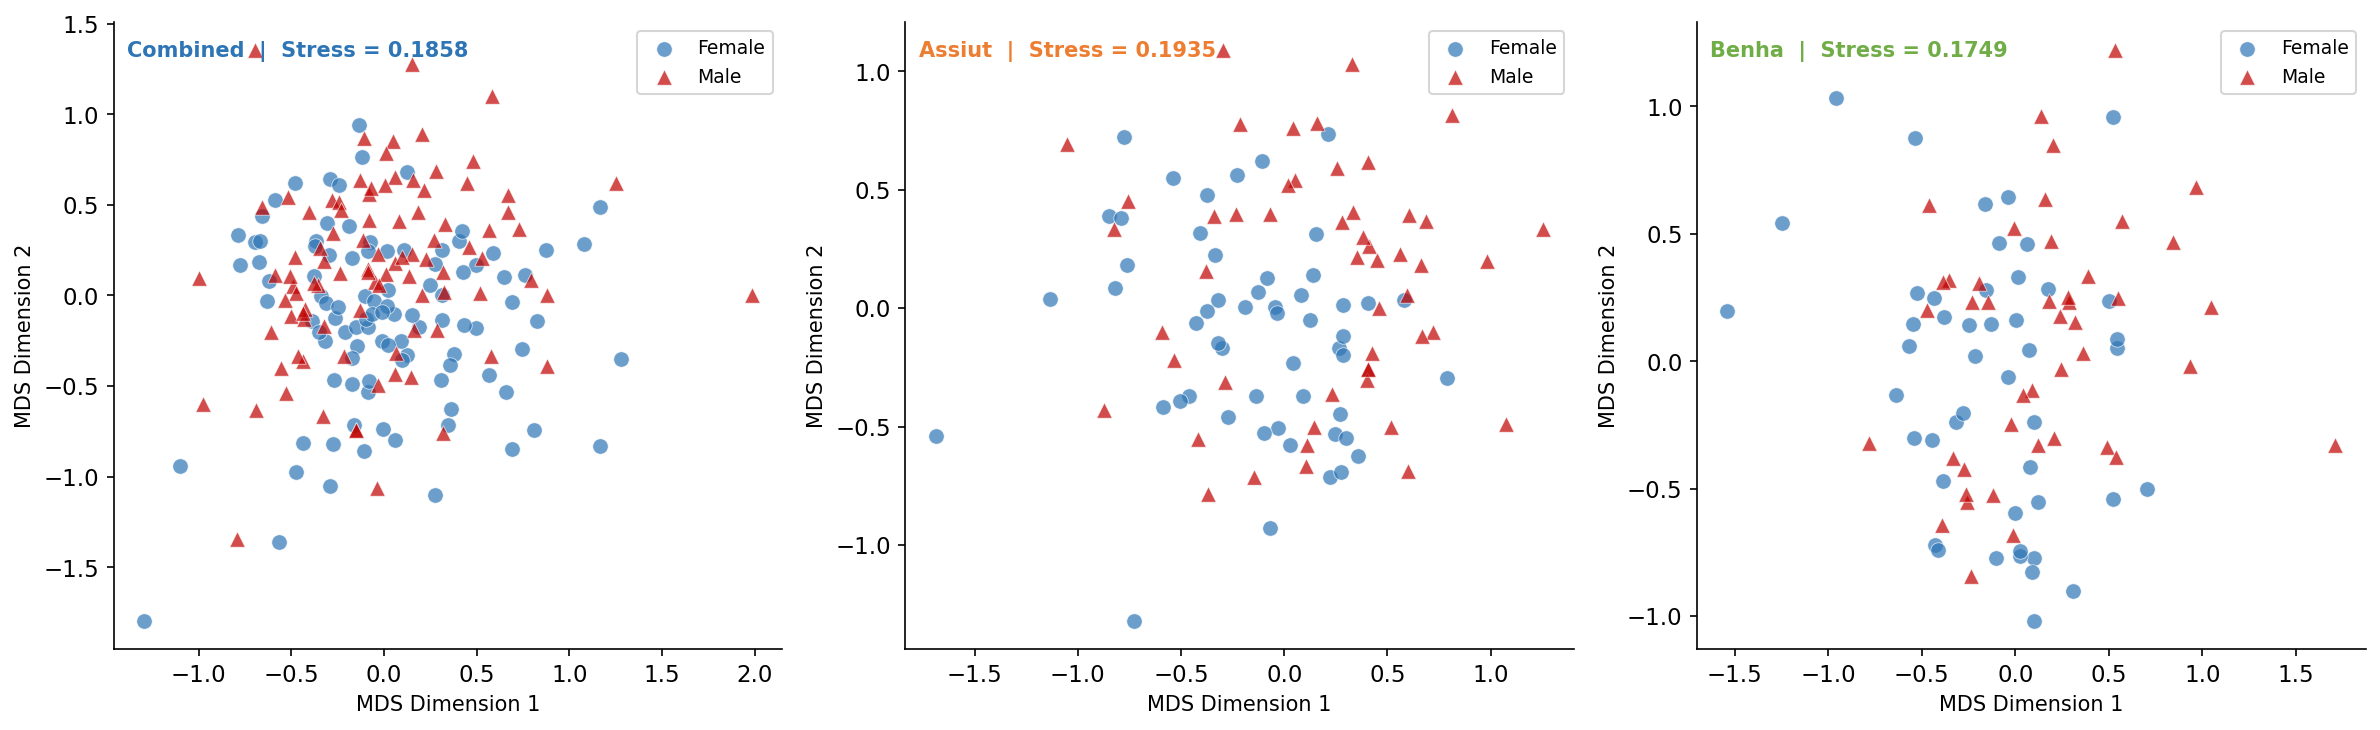

✅ Figure — nMDS saved


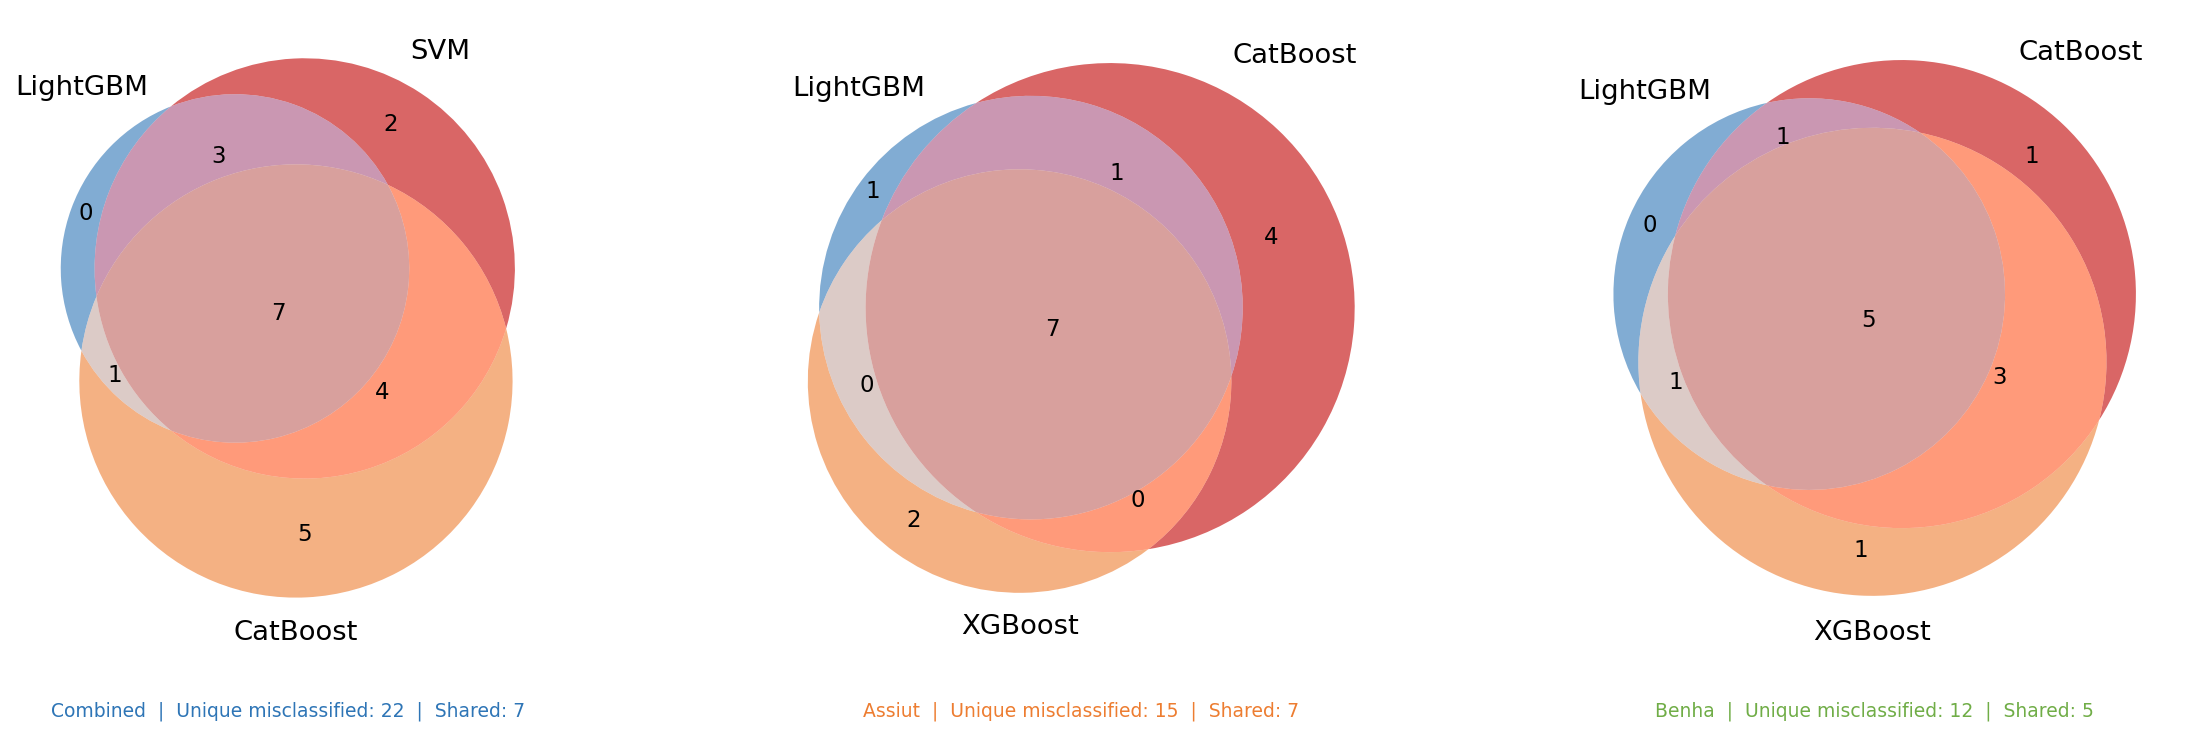

✅ Figure — Venn misclassified saved


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from matplotlib_venn import venn2, venn3
from sklearn.base import clone

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "savefig.facecolor": "white",
    "font.family":       "DejaVu Sans",
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        150,
})

COLORS = {"bar": ["#2E75B6", "#C00000", "#ED7D31", "#70AD47", "#7030A0", "#00B0F0"]}
DS_DISPLAY = {"All": "Combined", "Assiut": "Assiut", "Benha": "Benha"}

# ── Reference model: top AUC in Framework 2 (for nMDS features) ──
_ref = max(S2_COMBINATIONS, key=lambda x: x["test_auc"])
print(f"Reference model for nMDS: {_ref['model_name']} + {_ref['fs_name']}  (AUC={_ref['test_auc']:.3f})")

# Compute selected features per dataset
results = {}
for ds in DATASETS:
    if ds == "All":
        results[ds] = {"selected": _ref["selected"]}
    else:
        sel = _ref["fs_fn"](
            datasets[ds]["X_train"], datasets[ds]["y_train"],
            CV, _ref["model_name"], params=_ref["params"]
        )
        results[ds] = {"selected": sel}
    print(f"  {DS_DISPLAY[ds]}: {results[ds]['selected']}")

# ══════════════════════════════════════════════════════════════
# 1. nMDS — Sex group separation per dataset
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, ds in zip(axes, DATASETS):
    selected = results[ds]["selected"]
    X_all = pd.concat([
        datasets[ds]["X_train"][selected],
        datasets[ds]["X_test"][selected]
    ]).reset_index(drop=True)
    y_all = pd.concat([
        datasets[ds]["y_train"],
        datasets[ds]["y_test"]
    ]).reset_index(drop=True)

    X_scaled = StandardScaler().fit_transform(X_all)
    mds = MDS(
        n_components=2, metric=False, n_init=10, max_iter=500,
        dissimilarity="euclidean", random_state=SEED, normalized_stress="auto"
    )
    coords = mds.fit_transform(X_scaled)

    ax.scatter(
        coords[y_all == 0, 0], coords[y_all == 0, 1],
        c=COLORS["bar"][0], alpha=0.7, edgecolors="white",
        linewidth=0.4, s=55, label="Female"
    )
    ax.scatter(
        coords[y_all == 1, 0], coords[y_all == 1, 1],
        c=COLORS["bar"][1], alpha=0.7, edgecolors="white",
        linewidth=0.4, s=55, marker="^", label="Male"
    )

    ax.set_xlabel("MDS Dimension 1", fontsize=10)
    ax.set_ylabel("MDS Dimension 2", fontsize=10)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.text(0.02, 0.97, f"{DS_DISPLAY[ds]}  |  Stress = {mds.stress_:.4f}",
            transform=ax.transAxes, va="top", fontsize=10,
            color=COLORS_DS[ds], fontweight="bold")

plt.tight_layout()
plt.savefig("figures/fig5_nmds.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figure — nMDS saved")


# ══════════════════════════════════════════════════════════════
# 2. Venn Diagram — Misclassified subjects per model
# ══════════════════════════════════════════════════════════════

def get_misclassified(dataset_name, model_name, params, selected):
    X_tr = datasets[dataset_name]["X_train"][selected]
    y_tr = datasets[dataset_name]["y_train"]
    X_te = datasets[dataset_name]["X_test"][selected]
    y_te = datasets[dataset_name]["y_test"]
    m = clone(build_model(model_name, params))
    m.fit(X_tr, y_tr)
    y_pred = m.predict(X_te)
    return set(np.where(y_pred != y_te.values)[0])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, ds in zip(axes, DATASETS):
    color    = COLORS_DS[ds]
    selected = results[ds]["selected"]

    model_miss = {}
    for model_name in MODEL_NAMES:
        params = s2_tuned_params[model_name]
        model_miss[model_name] = get_misclassified(ds, model_name, params, selected)

    models = list(model_miss.keys())

    # Choose 3 models most related to reference model
    overlap_scores = {m: len(model_miss[m] & model_miss[_ref["model_name"]])
                      for m in models if m != _ref["model_name"]}
    top2_overlap = sorted(overlap_scores, key=overlap_scores.get, reverse=True)[:2]
    sel_models = [_ref["model_name"]] + top2_overlap
    sel_sets   = [model_miss[m] for m in sel_models]

    if len(sel_models) == 3:
        v = venn3(subsets=sel_sets, set_labels=sel_models, ax=ax,
                  set_colors=[COLORS["bar"][0], COLORS["bar"][1], COLORS["bar"][2]], alpha=0.6)
    else:
        v = venn2(subsets=sel_sets[:2], set_labels=sel_models[:2], ax=ax,
                  set_colors=[COLORS["bar"][0], COLORS["bar"][1]], alpha=0.6)

    all_miss = set().union(*sel_sets)
    shared   = set.intersection(*sel_sets)
    ax.text(0.5, -0.12,
            f"{DS_DISPLAY[ds]}  |  Unique misclassified: {len(all_miss)}  |  Shared: {len(shared)}",
            transform=ax.transAxes, ha="center", fontsize=9, color=color)
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)

plt.tight_layout()
plt.savefig("figures/fig6_venn_misclassified.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figure — Venn misclassified saved")

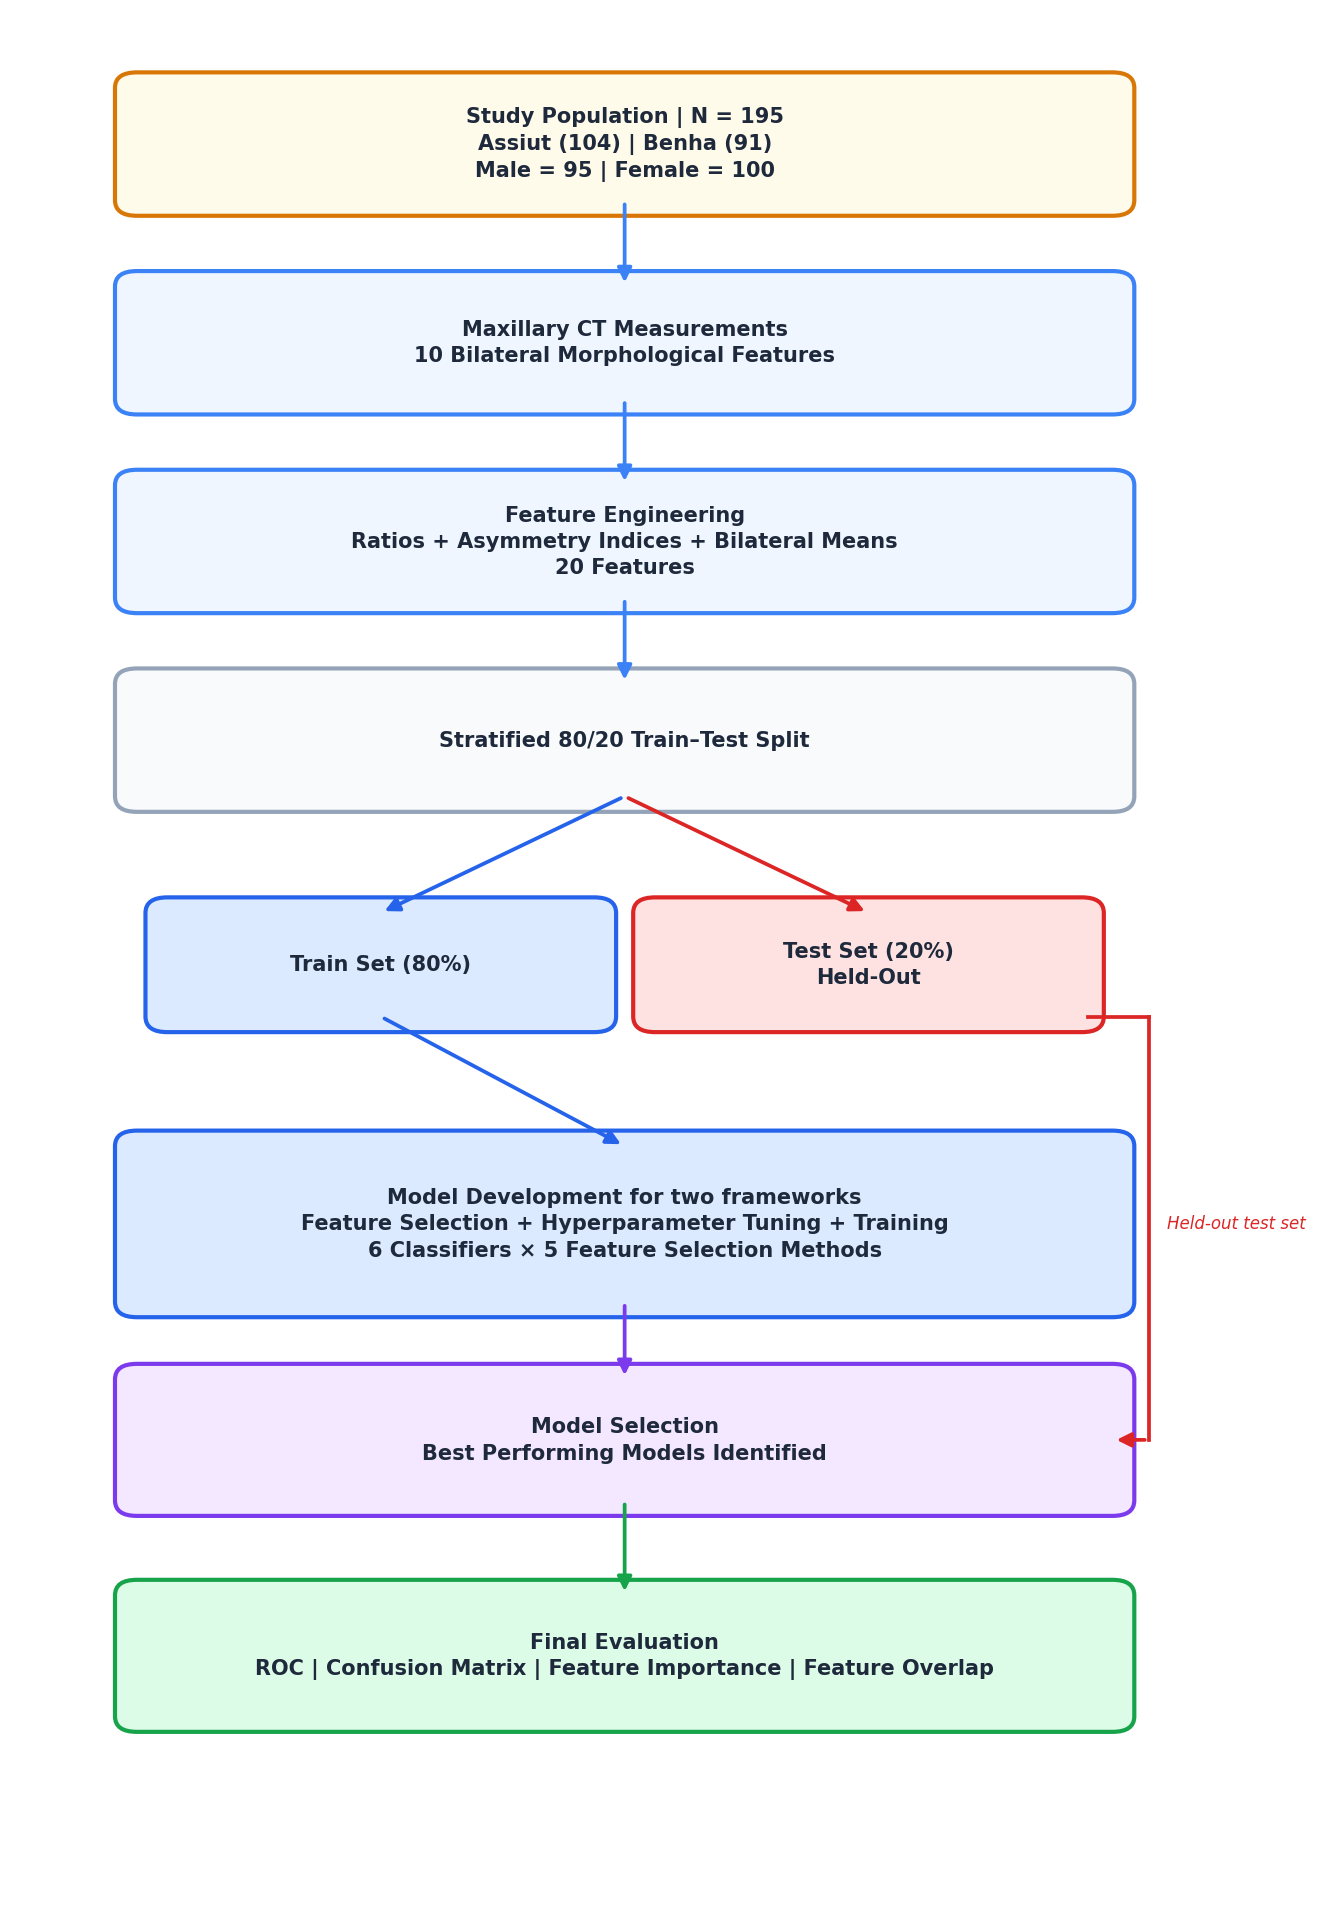

Figure 1 saved


In [15]:
# ════════════════════════════════════════════════════════════════
# Figure 1 — Overall Study Design
# ════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

plt.rcParams.update({"font.family": "DejaVu Sans"})

# ── Colors ────────────────────────────────────────────────────
POP   = ("#FFFBEB", "#D97706")
DATA  = ("#EFF6FF", "#3B82F6")
NEUT  = ("#F8FAFC", "#94A3B8")
TRAIN = ("#DBEAFE", "#2563EB")
SEL   = ("#F3E8FF", "#7C3AED")
EVAL  = ("#DCFCE7", "#16A34A")
TEST  = ("#FEE2E2", "#DC2626")
TC    = "#1E293B"

def _box(ax, cx, cy, w, h, txt, fc, ec, fs=10, lw=2):
    ax.add_patch(
        FancyBboxPatch(
            (cx - w/2, cy - h/2),
            w,
            h,
            boxstyle="round,pad=0.18",
            facecolor=fc,
            edgecolor=ec,
            linewidth=lw,
            clip_on=False
        )
    )

    ax.text(
        cx,
        cy,
        txt,
        ha="center",
        va="center",
        fontsize=fs,
        color=TC,
        fontweight="bold",
        multialignment="center",
        linespacing=1.4
    )

def _arr(ax, x1, y1, x2, y2, color="#94A3B8", lw=1.8):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            lw=lw,
            mutation_scale=14
        )
    )

# ── Canvas ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 13))

ax.set_xlim(0, 10)
ax.set_ylim(0, 22)

ax.axis("off")

BW = 8.0
BH = 1.3

# ── Main pipeline ─────────────────────────────────────────────
_box(
    ax, 5, 20.5, BW, BH,
    "Study Population | N = 195\nAssiut (104) | Benha (91)\nMale = 95 | Female = 100",
    *POP
)

_box(
    ax, 5, 18.2, BW, BH,
    "Maxillary CT Measurements\n10 Bilateral Morphological Features",
    *DATA
)

_box(
    ax, 5, 15.9, BW, BH,
    "Feature Engineering\nRatios + Asymmetry Indices + Bilateral Means\n20 Features",
    *DATA
)

_box(
    ax, 5, 13.6, BW, BH,
    "Stratified 80/20 Train–Test Split",
    *NEUT
)

# ── Train / Test ──────────────────────────────────────────────
_box(
    ax, 3.0, 11.0, 3.5, 1.2,
    "Train Set (80%)",
    *TRAIN
)

_box(
    ax, 7.0, 11.0, 3.5, 1.2,
    "Test Set (20%)\nHeld-Out",
    *TEST
)

# ── Model Development ─────────────────────────────────────────
_box(
    ax, 5.0, 8.0, BW, 1.8,
    "Model Development for two frameworks\nFeature Selection + Hyperparameter Tuning + Training\n6 Classifiers × 5 Feature Selection Methods",
    *TRAIN
)

_box(
    ax, 5.0, 5.5, BW, 1.4,
    "Model Selection\nBest Performing Models Identified",
    *SEL
)

_box(
    ax, 5.0, 3.0, BW, 1.4,
    "Final Evaluation\nROC | Confusion Matrix | Feature Importance | Feature Overlap",
    *EVAL
)

# ── Main arrows ───────────────────────────────────────────────
_arr(ax, 5, 19.85, 5, 18.85, DATA[1])
_arr(ax, 5, 17.55, 5, 16.55, DATA[1])
_arr(ax, 5, 15.25, 5, 14.25, DATA[1])

# Split
_arr(ax, 5, 12.95, 3.0, 11.6, TRAIN[1])
_arr(ax, 5, 12.95, 7.0, 11.6, TEST[1])

# Train → Development
_arr(ax, 3.0, 10.4, 5.0, 8.9, TRAIN[1])

# Development → Selection
_arr(ax, 5.0, 7.1, 5.0, 6.2, SEL[1])

# Selection → Final
_arr(ax, 5.0, 4.8, 5.0, 3.7, EVAL[1])


# ── Test set routed to Model Selection ───────────────────────

px = 9.3

# horizontal segment from test box
ax.plot(
    [8.8, px],
    [10.4, 10.4],
    color=TEST[1],
    lw=1.8
)

# vertical segment (Now stops at 5.5 which is the y-level of Model Selection)
ax.plot(
    [px, px],
    [10.4, 5.5],
    color=TEST[1],
    lw=1.8
)

# arrow into Model Selection
_arr(
    ax,
    px,
    5.5,
    5.0 + BW/2, # right edge of the box
    5.5,
    TEST[1]
)

# annotation
ax.text(
    px + 0.15,
    8.0, # adjusted y to be visually centered on the new line length
    "Held-out test set",
    fontsize=8,
    color=TEST[1],
    style="italic",
    ha="left",
    va="center"
)

plt.tight_layout()

plt.savefig(
    "figures/Figure1_study_design.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Figure 1 saved")

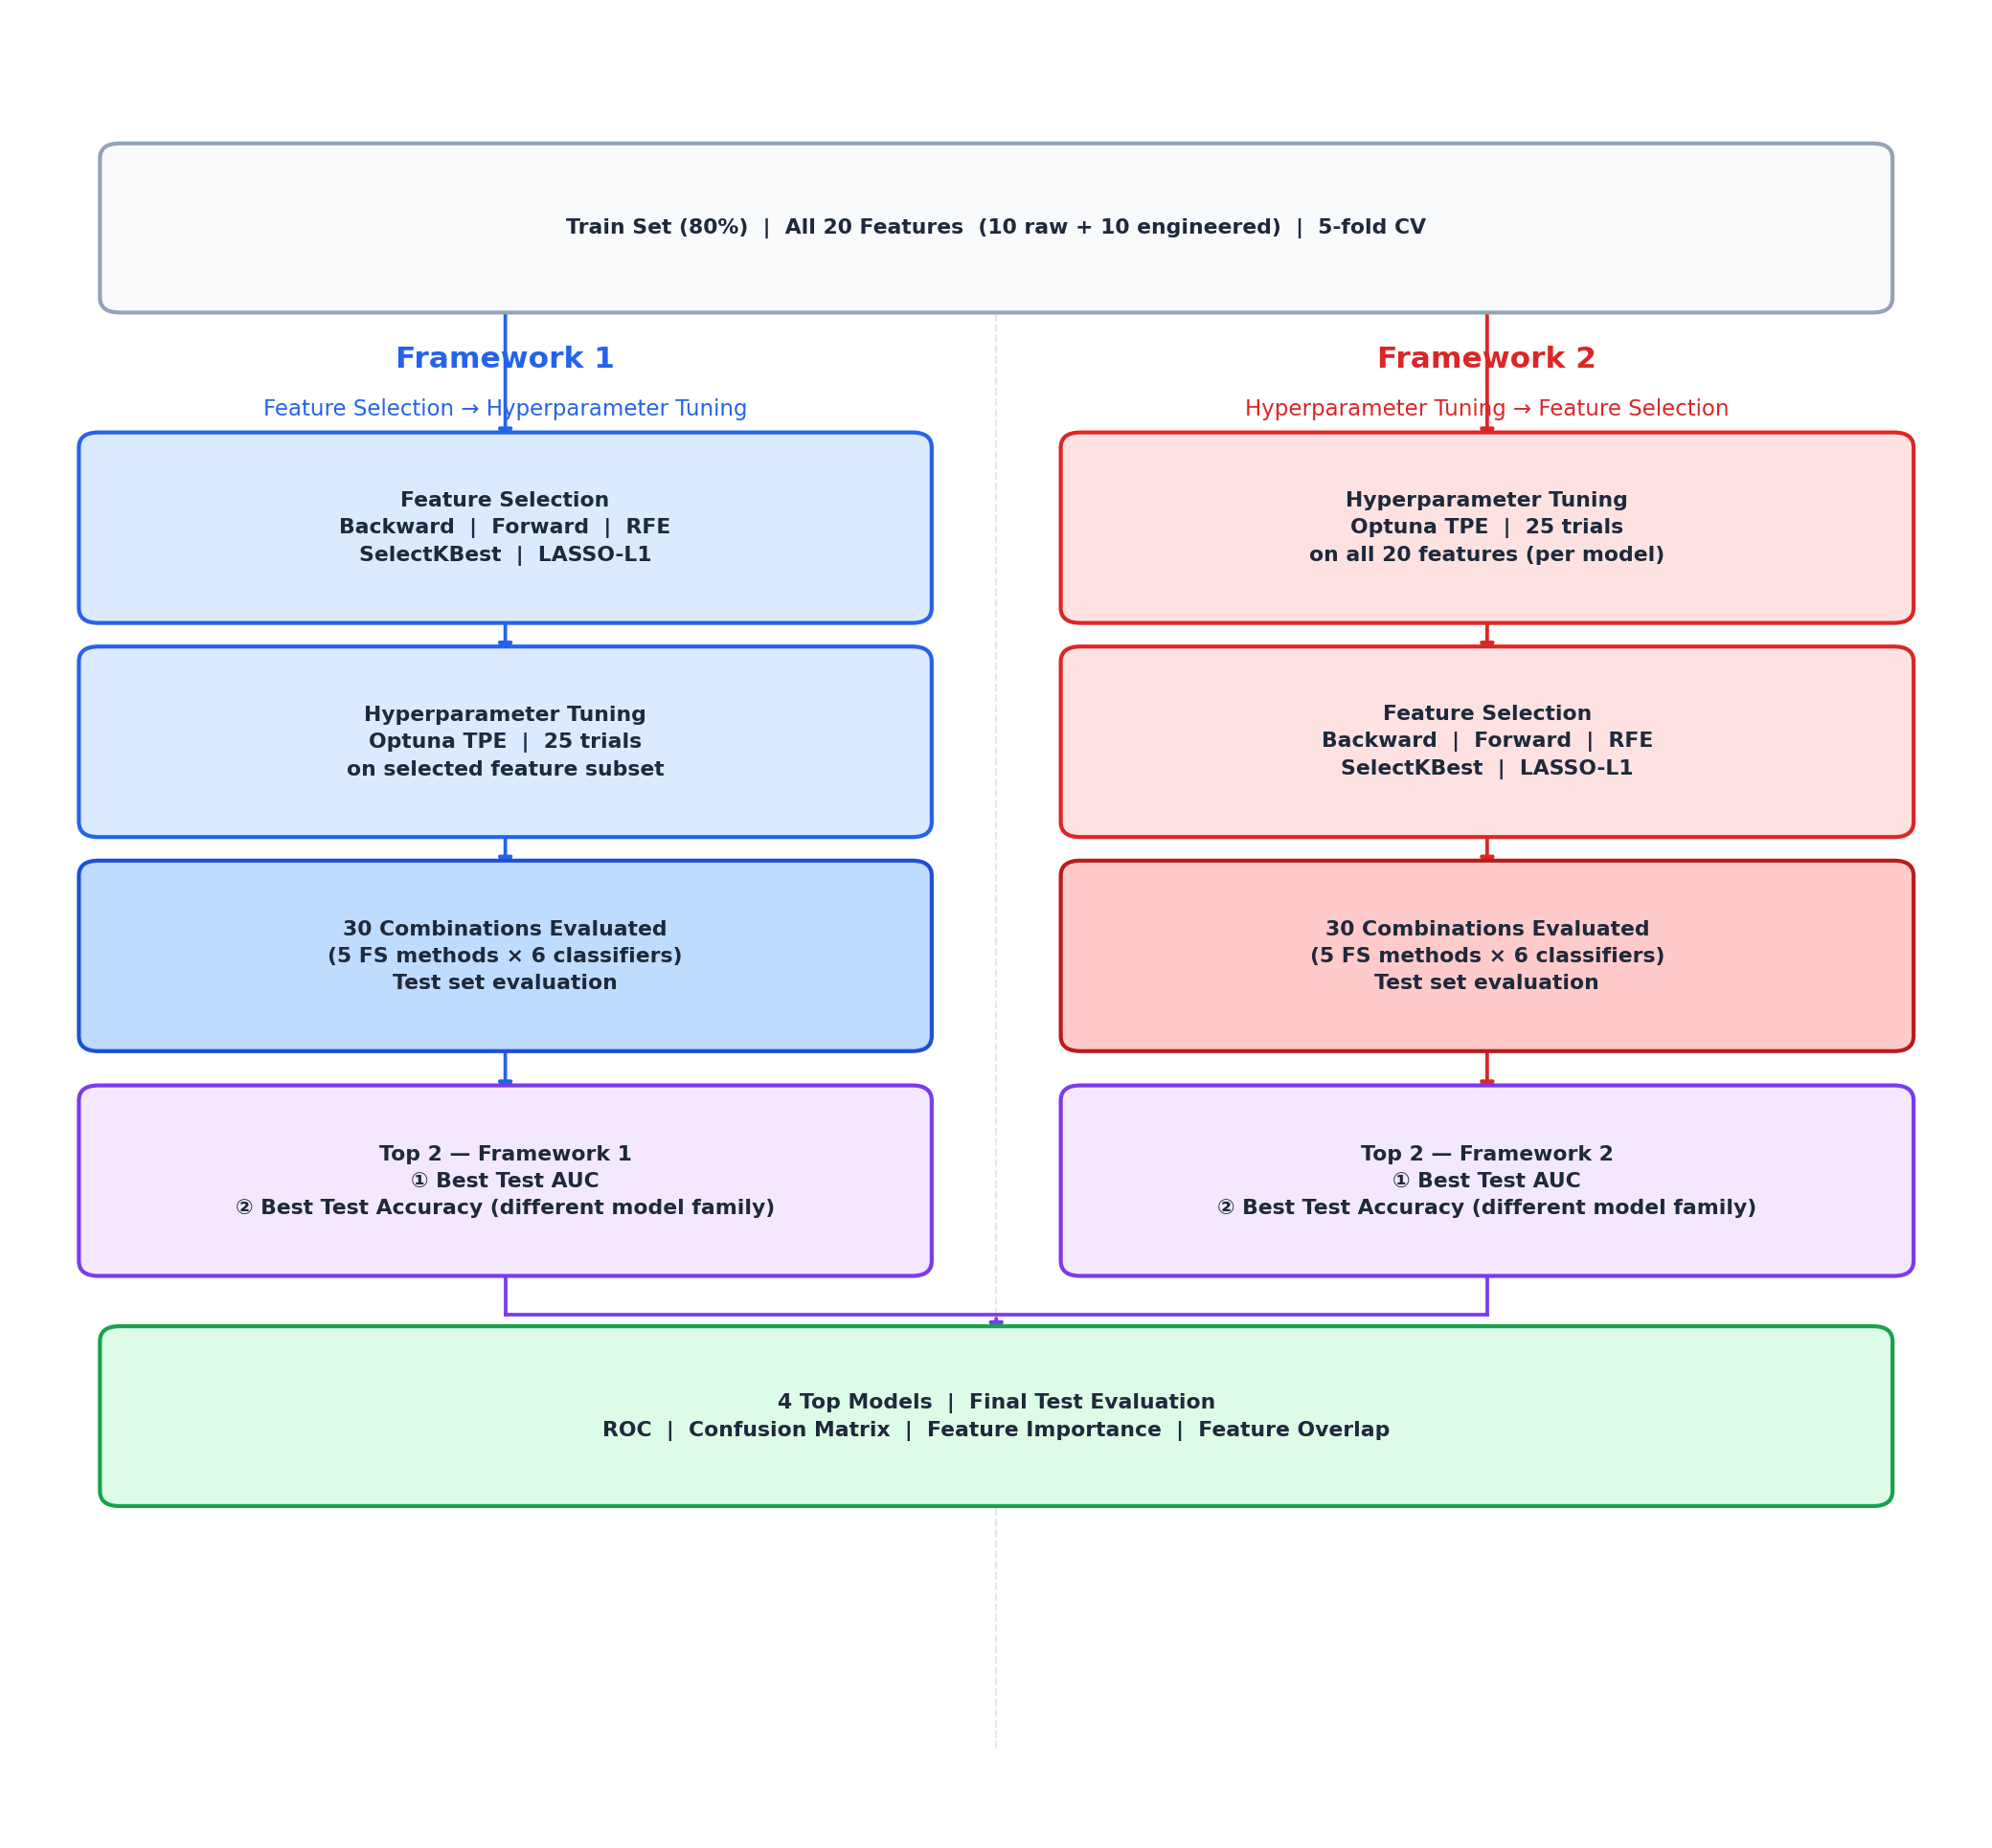

Figure 2 saved


In [16]:
# ════════════════════════════════════════════════════════════════
# Figure 2 — Two Modeling Frameworks Overview
# ════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

plt.rcParams.update({"font.family": "DejaVu Sans"})

# ── Shared light palette (same as Figure 1 for consistency) ──
NEUT  = ("#F8FAFC", "#94A3B8")
TRAIN = ("#DBEAFE", "#2563EB")          # F1 — light blue
F1D   = ("#BFDBFE", "#1D4ED8")          # F1 step boxes — slightly richer
TEST  = ("#FEE2E2", "#DC2626")          # F2 — light rose-red
F2D   = ("#FECACA", "#B91C1C")          # F2 step boxes — slightly richer
SEL   = ("#F3E8FF", "#7C3AED")          # Top-2 — light lavender
EVAL  = ("#DCFCE7", "#16A34A")          # Eval — light green
TC    = "#1E293B"

def _box(ax, cx, cy, w, h, txt, fc, ec, fs=10.5, lw=2.0):
    ax.add_patch(FancyBboxPatch(
        (cx - w/2, cy - h/2), w, h,
        boxstyle="round,pad=0.14",
        facecolor=fc, edgecolor=ec,
        linewidth=lw, zorder=2, clip_on=False
    ))
    ax.text(cx, cy, txt, ha="center", va="center",
            fontsize=fs, color=TC, fontweight="bold",
            multialignment="center", zorder=3, linespacing=1.5)

def _arr(ax, x1, y1, x2, y2, color="#94A3B8", lw=1.8):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color,
                                lw=lw, mutation_scale=14), zorder=1)

fig, ax = plt.subplots(figsize=(14, 13))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.set_xlim(0, 14)
ax.set_ylim(0, 17)
ax.axis("off")

BW2, BH2 = 5.8, 1.5
cx1, cx2  = 3.5, 10.5

ax.plot([7.0, 7.0], [0.8, 15.3], color="#E2E8F0", lw=1.0, ls="--", zorder=0)

# ── Shared top ──
_box(ax, 7.0, 15.0, 12.5, 1.3,
     "Train Set (80%)  |  All 20 Features  (10 raw + 10 engineered)  |  5-fold CV",
     *NEUT)

# ── Framework headers ──
ax.text(cx1, 13.7, "Framework 1", ha="center", fontsize=15,
        color=TRAIN[1], fontweight="bold")
ax.text(cx1, 13.25, "Feature Selection → Hyperparameter Tuning",
        ha="center", fontsize=11, color=TRAIN[1])
ax.text(cx2, 13.7, "Framework 2", ha="center", fontsize=15,
        color=TEST[1], fontweight="bold")
ax.text(cx2, 13.25, "Hyperparameter Tuning → Feature Selection",
        ha="center", fontsize=11, color=TEST[1])

# ── Framework 1 steps ──
for y, txt in [
    (12.2, "Feature Selection\nBackward  |  Forward  |  RFE\nSelectKBest  |  LASSO-L1"),
    (10.2, "Hyperparameter Tuning\nOptuna TPE  |  25 trials\non selected feature subset"),
    ( 8.2, "30 Combinations Evaluated\n(5 FS methods × 6 classifiers)\nTest set evaluation"),
]:
    fc, ec = (F1D if y == 8.2 else TRAIN)
    _box(ax, cx1, y, BW2, BH2, txt, fc, ec)

# ── Framework 2 steps ──
for y, txt in [
    (12.2, "Hyperparameter Tuning\nOptuna TPE  |  25 trials\non all 20 features (per model)"),
    (10.2, "Feature Selection\nBackward  |  Forward  |  RFE\nSelectKBest  |  LASSO-L1"),
    ( 8.2, "30 Combinations Evaluated\n(5 FS methods × 6 classifiers)\nTest set evaluation"),
]:
    fc, ec = (F2D if y == 8.2 else TEST)
    _box(ax, cx2, y, BW2, BH2, txt, fc, ec)

# ── Top 2 per framework ──
_box(ax, cx1, 6.1, BW2, BH2,
     "Top 2 — Framework 1\n① Best Test AUC\n② Best Test Accuracy (different model family)",
     *SEL)
_box(ax, cx2, 6.1, BW2, BH2,
     "Top 2 — Framework 2\n① Best Test AUC\n② Best Test Accuracy (different model family)",
     *SEL)

# ── Shared bottom ──
_box(ax, 7.0, 3.9, 12.5, 1.4,
     "4 Top Models  |  Final Test Evaluation\nROC  |  Confusion Matrix  |  Feature Importance  |  Feature Overlap",
     *EVAL)

# ── Arrows ──
for y1, y2, col in [
    (15.0, 12.2, TRAIN[1]), (12.2, 10.2, TRAIN[1]),
    (10.2, 8.2,  TRAIN[1]), (8.2,  6.1,  TRAIN[1])
]:
    _arr(ax, cx1, y1 - BH2/2, cx1, y2 + BH2/2, col)

for y1, y2, col in [
    (15.0, 12.2, TEST[1]), (12.2, 10.2, TEST[1]),
    (10.2, 8.2,  TEST[1]), (8.2,  6.1,  TEST[1])
]:
    _arr(ax, cx2, y1 - BH2/2, cx2, y2 + BH2/2, col)

my = 4.85
ax.plot([cx1, cx1], [6.1 - BH2/2, my], color=SEL[1], lw=1.8, zorder=1)
ax.plot([cx2, cx2], [6.1 - BH2/2, my], color=SEL[1], lw=1.8, zorder=1)
ax.plot([cx1, cx2], [my, my],           color=SEL[1], lw=1.8, zorder=1)
_arr(ax, 7.0, my, 7.0, 3.9 + 1.4/2, SEL[1])

plt.tight_layout()
plt.savefig("figures/Figure2_frameworks_overview.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Figure 2 saved")

Framework 1 — Top 2 models:
  [Best AUC] CatBoost + Backward  (AUC=0.771, Acc=0.692)
  [Best Accuracy] RandomForest + RFE  (AUC=0.700, Acc=0.718)

Framework 2 — Top 2 models:
  [Best AUC] LightGBM + RFE  (AUC=0.768, Acc=0.718)
  [Best Accuracy] LightGBM + Backward  (AUC=0.766, Acc=0.744)

Computing predictions...
  ✓ F1  Best AUC: CatBoost + Backward
  ✓ F1  Best Accuracy: RandomForest + RFE
  ✓ F2  Best AUC: LightGBM + RFE
  ✓ F2  Best Accuracy: LightGBM + Backward
Done ✅



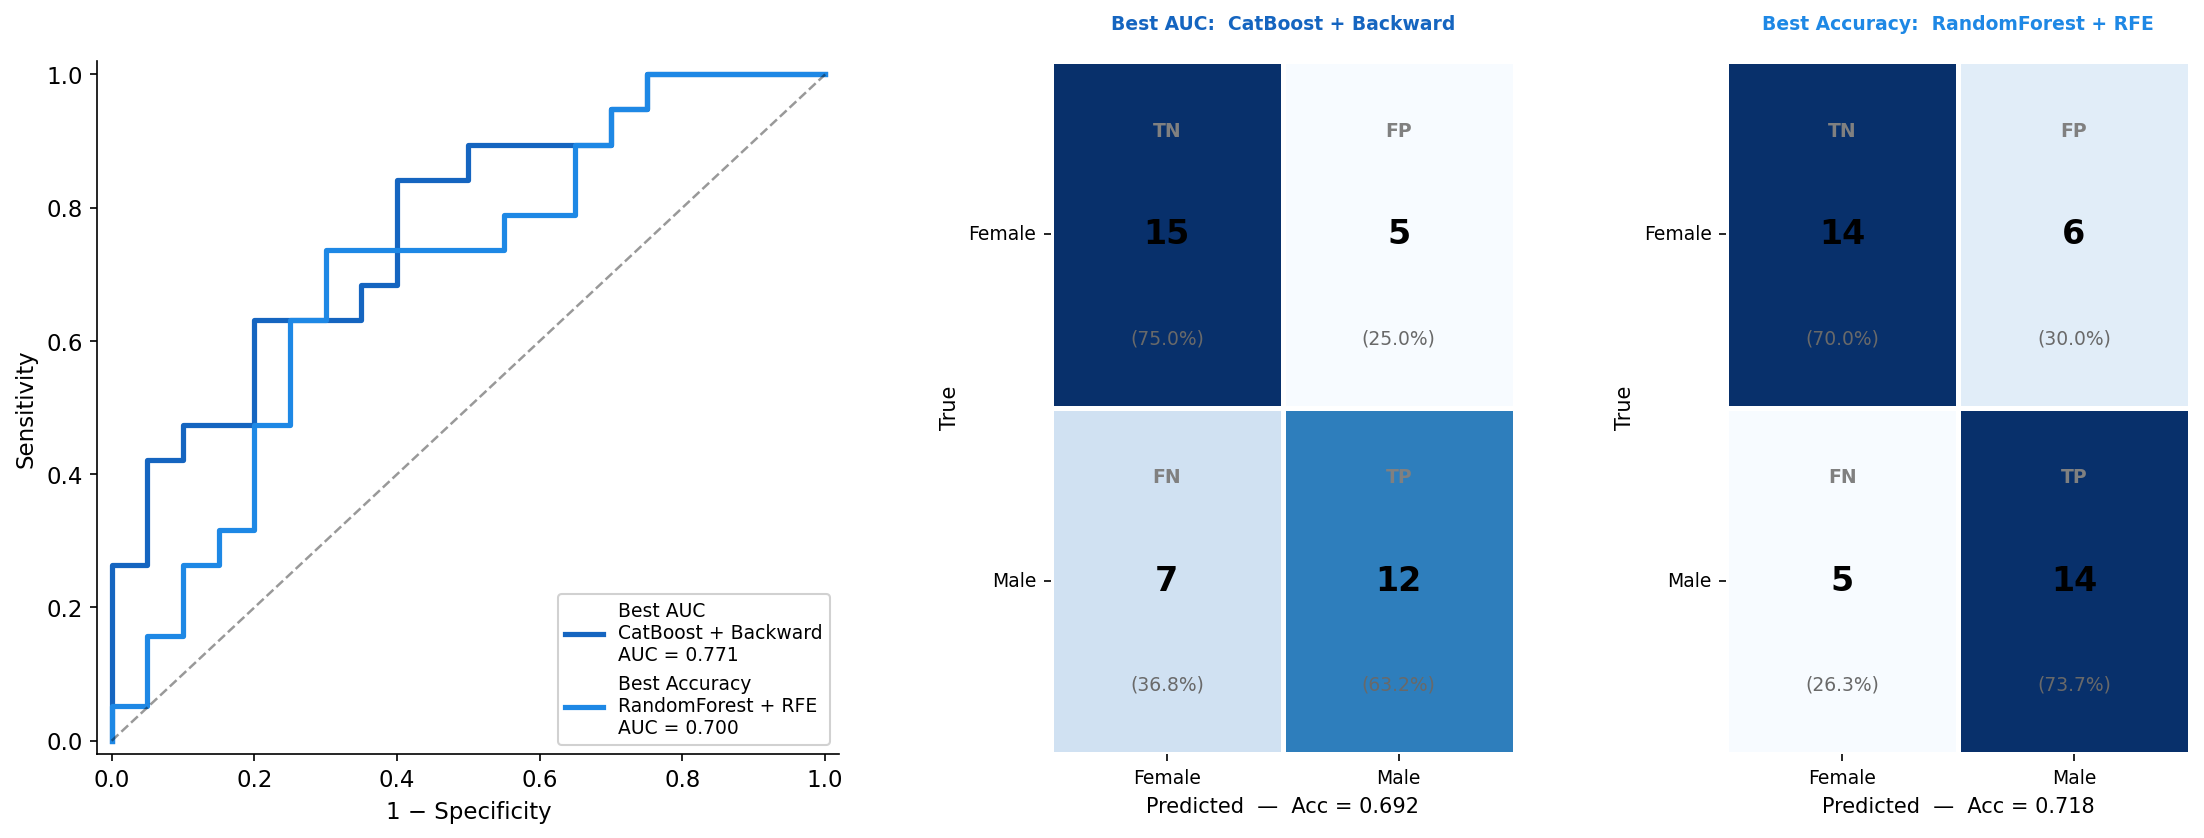

✅ fig_new_framework1_roc_cm.png saved


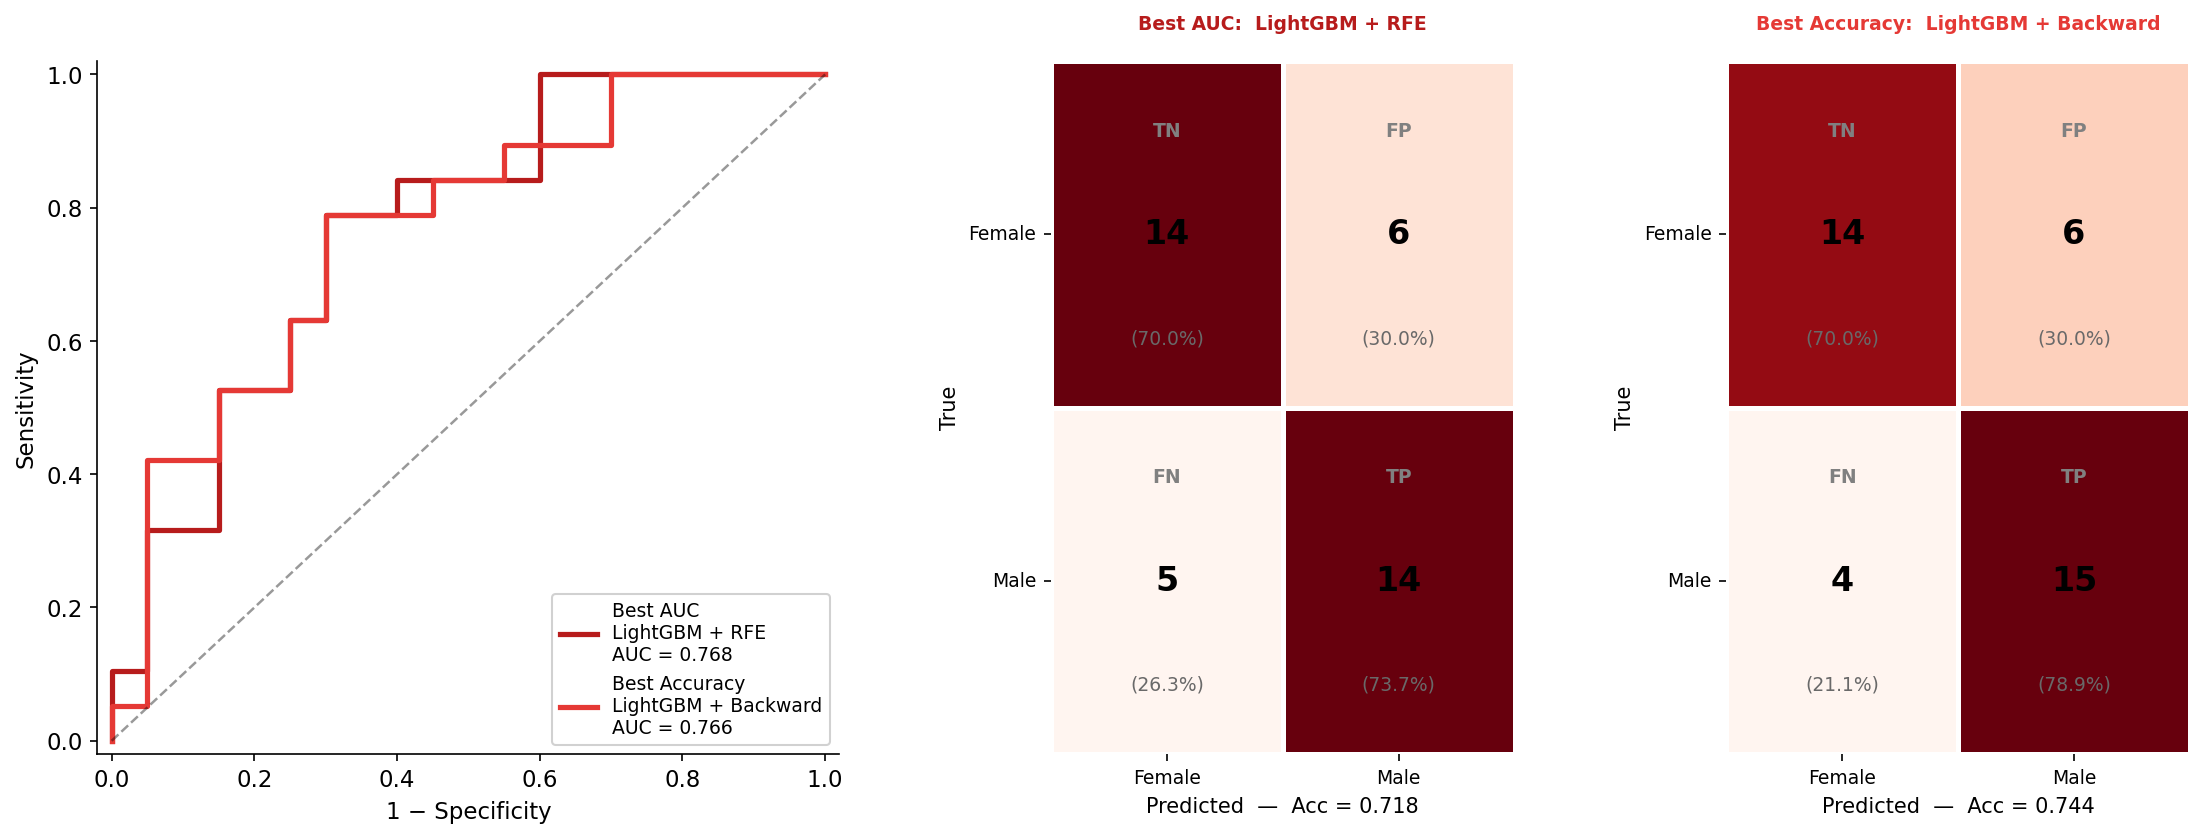

✅ fig_new_framework2_roc_cm.png saved


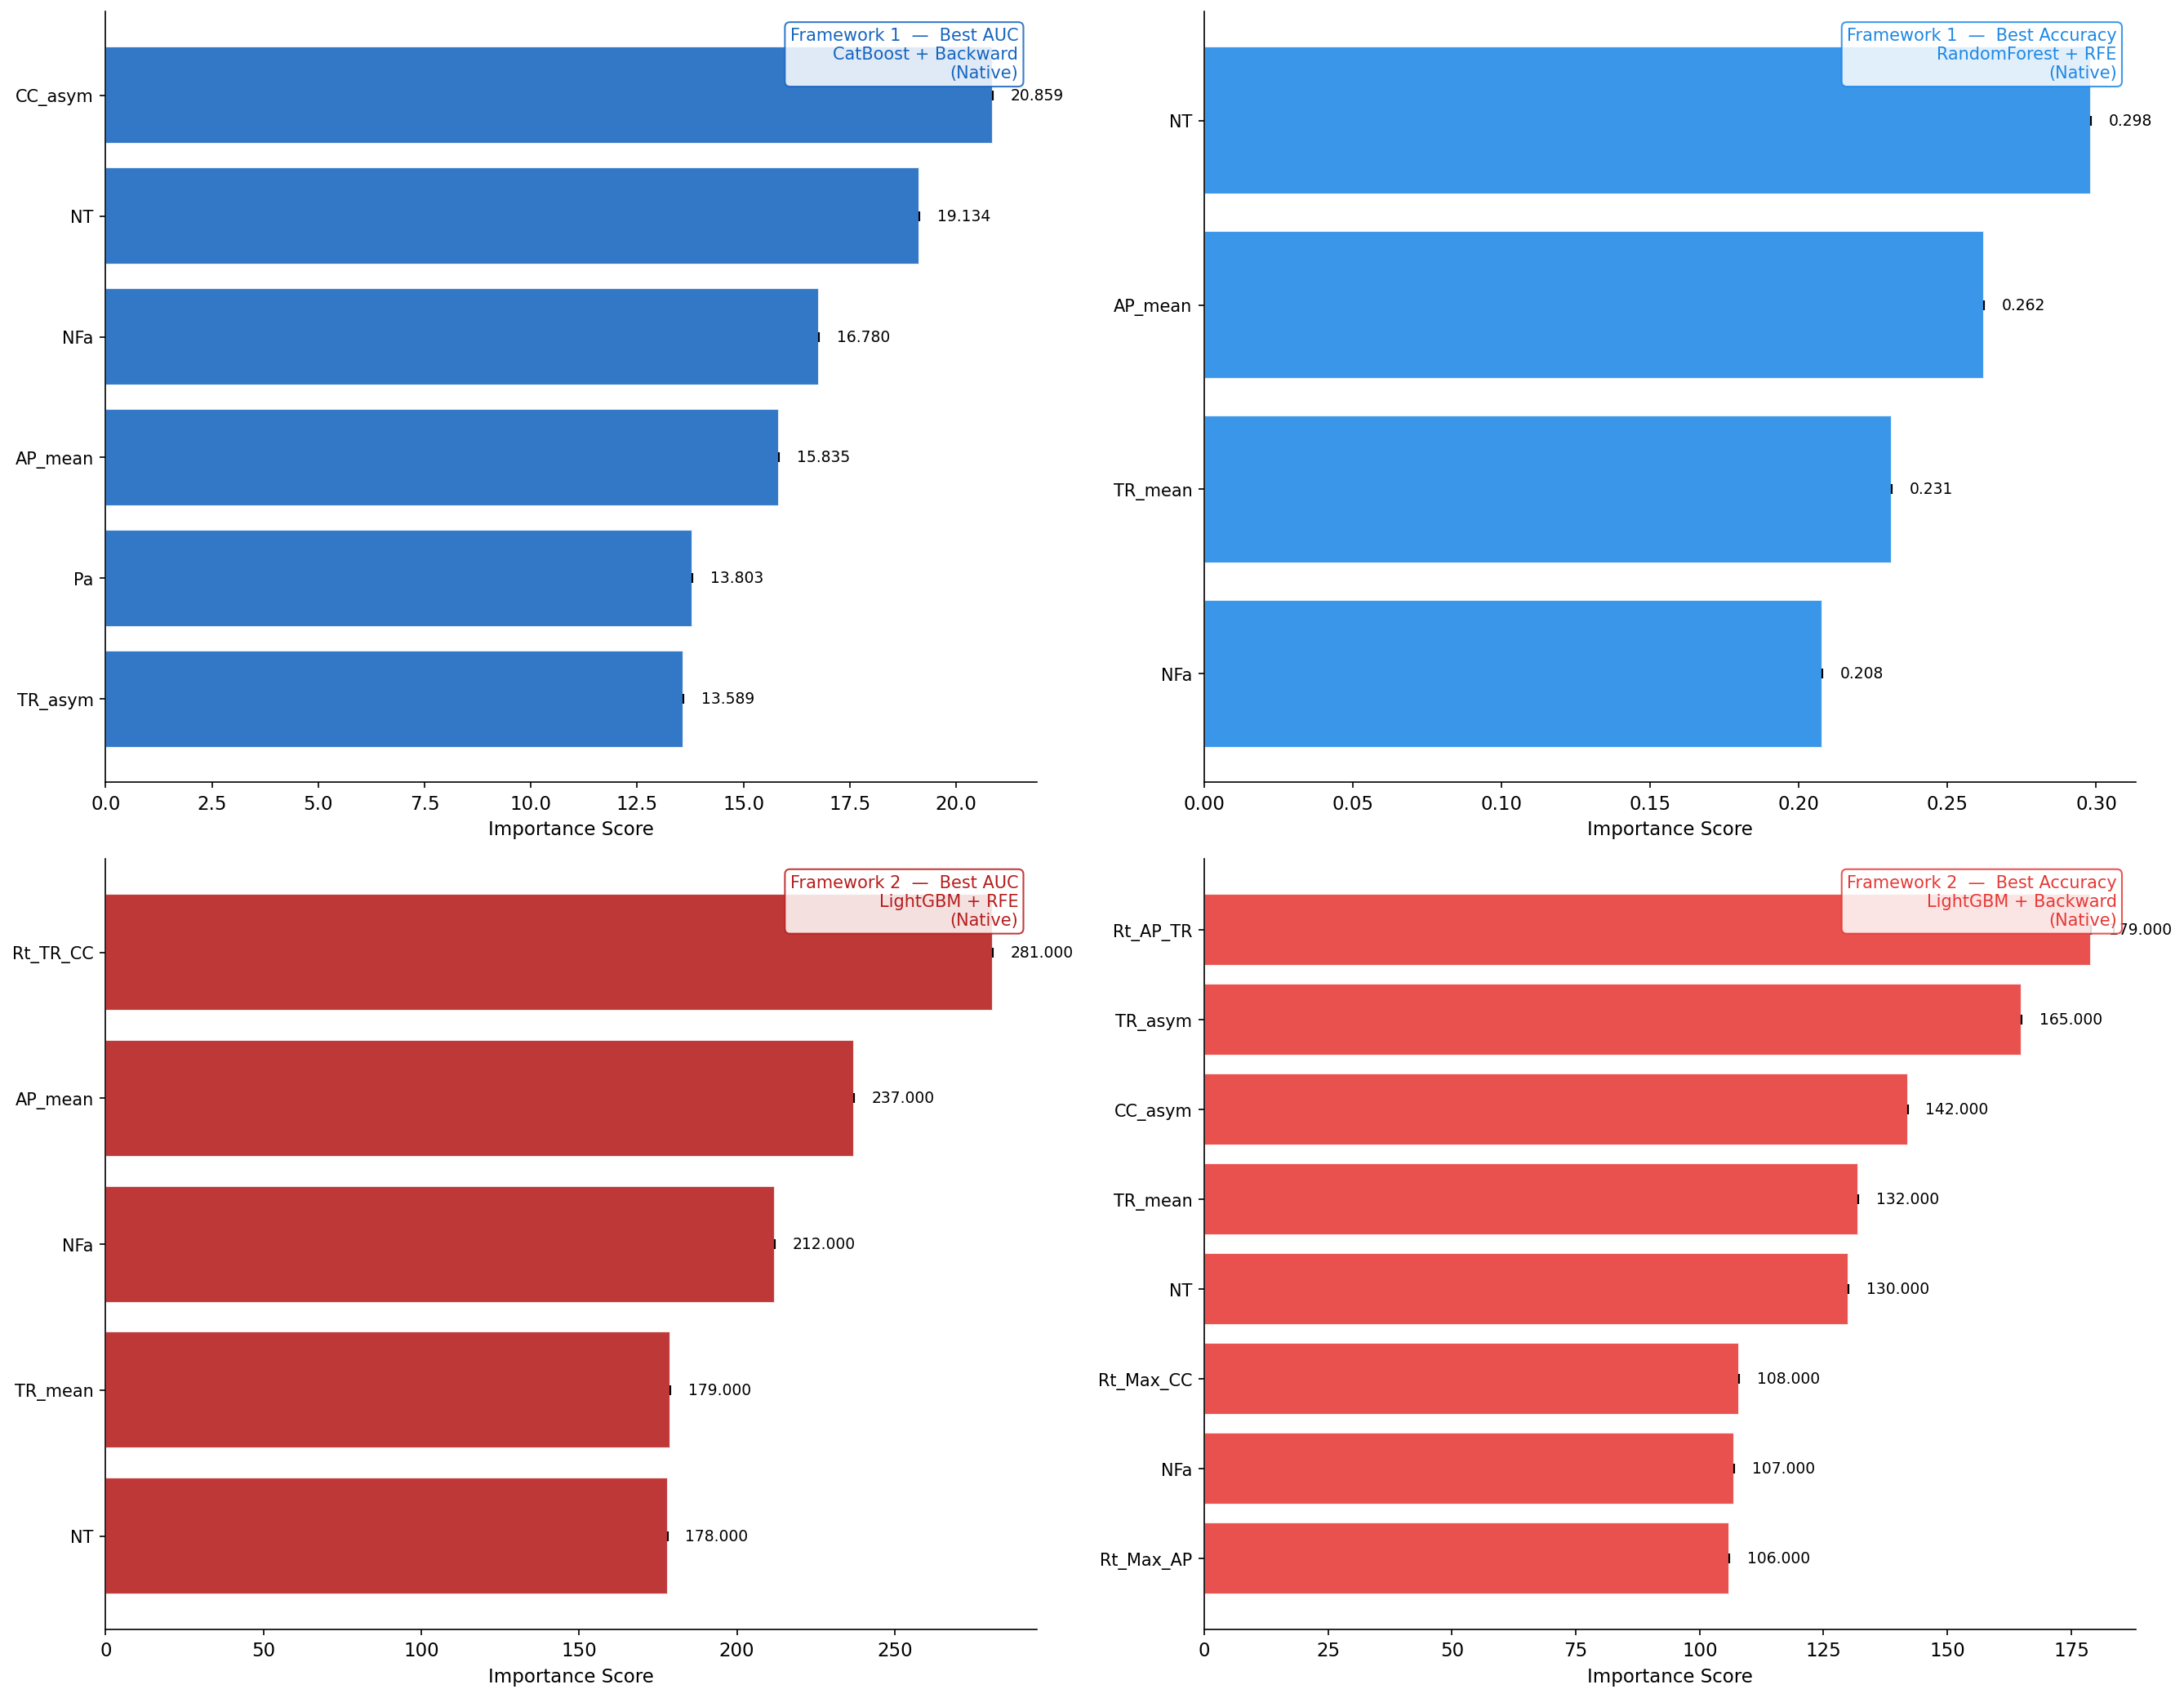

✅ fig_new_feature_importance_top4.png saved


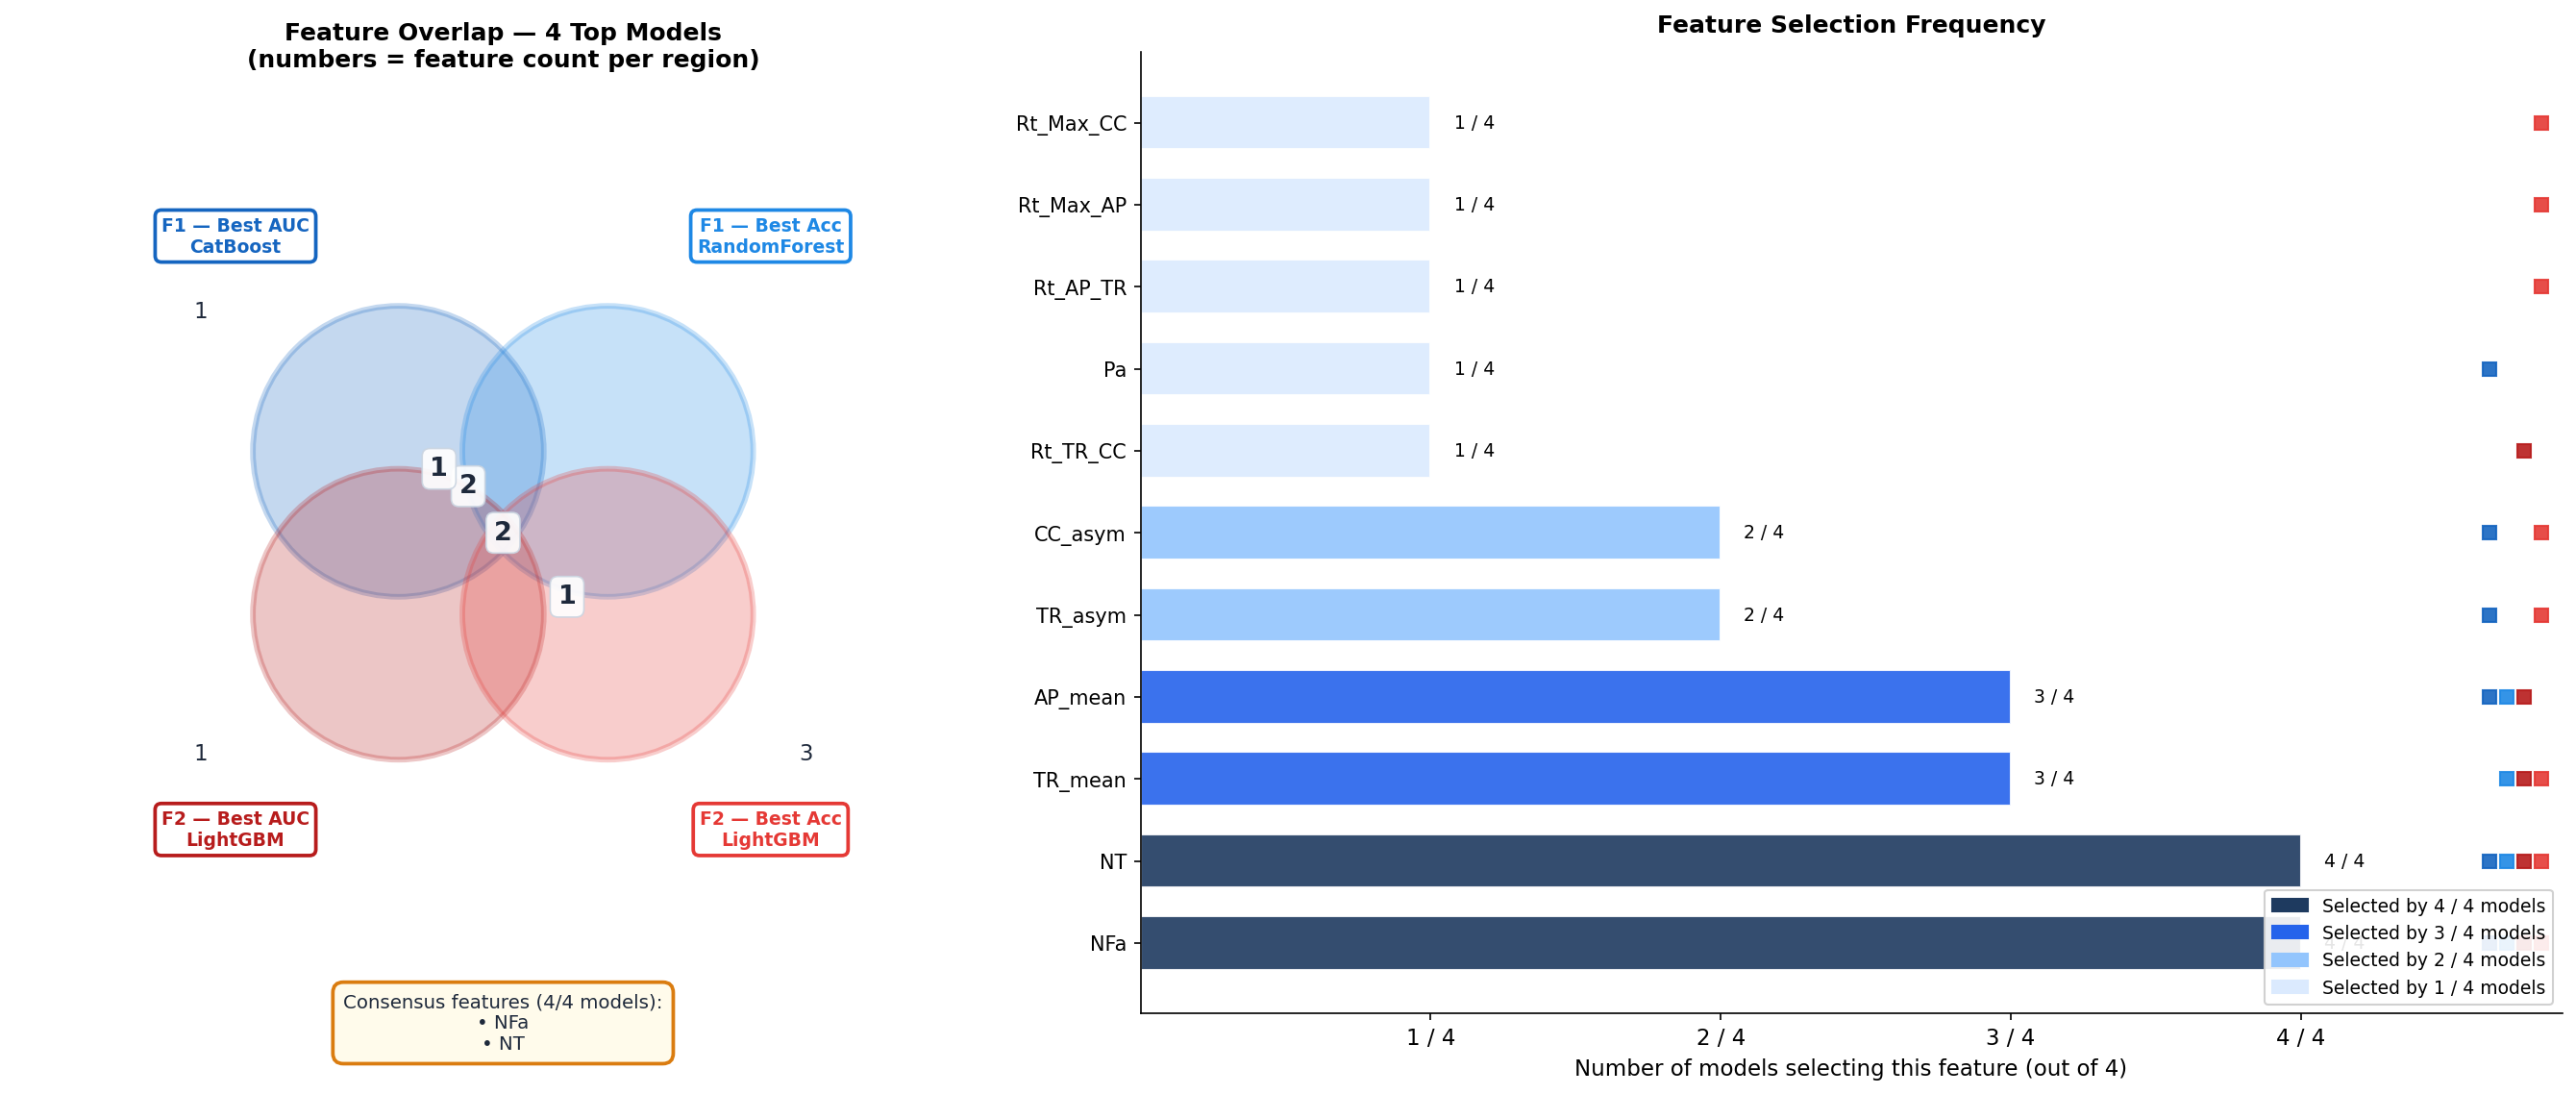

✅ fig_new_venn_shared_features.png saved


In [17]:
# ══════════════════════════════════════════════════════════════
# TOP 2 MODELS PER FRAMEWORK — New Publication Figures
# ══════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import Circle
import numpy as np
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score
from sklearn.inspection import permutation_importance
from sklearn.base import clone

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "savefig.facecolor": "white",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 150,
})

# ── Ensure test_accuracy exists in combinations (fallback from ALL_RESULTS) ──
def _ensure_accuracy(combinations, scenario_key):
    if not combinations or "test_accuracy" in combinations[0]:
        return
    lookup = {
        (r["FS_Method"], r["Model"]): r["test_accuracy"]
        for r in ALL_RESULTS.get((scenario_key, "All"), [])
    }
    for c in combinations:
        c["test_accuracy"] = lookup.get((c["fs_name"], c["model_name"]), c["test_auc"])

_ensure_accuracy(S1_COMBINATIONS, "S1_FS_then_Tune")
_ensure_accuracy(S2_COMBINATIONS, "S2_Tune_then_FS")

# ── Select top 2: best AUC + best Accuracy from a DIFFERENT model family ──
def _get_top2(combinations, color1, color2):
    by_auc = sorted(combinations, key=lambda x: x["test_auc"],      reverse=True)
    by_acc = sorted(combinations, key=lambda x: x["test_accuracy"], reverse=True)

    top_auc = by_auc[0]

    # Best Accuracy — any model family allowed, must be a different combination
    top_acc = next(
        (c for c in by_acc
         if not (c["model_name"] == top_auc["model_name"]
                 and c["fs_name"]  == top_auc["fs_name"])),
        by_acc[1] if len(by_acc) > 1 else by_acc[0]
    )

    return [
        {**top_auc, "rank": "Best AUC",      "color": color1},
        {**top_acc, "rank": "Best Accuracy",  "color": color2},
    ]

# ── Stronger, publication-quality colors ──
F1_COLORS = ["#1565C0", "#1E88E5"]   # dark blue + medium blue
F2_COLORS = ["#B71C1C", "#E53935"]   # dark red  + medium red

S1_TOP2 = _get_top2(S1_COMBINATIONS, *F1_COLORS)
S2_TOP2 = _get_top2(S2_COMBINATIONS, *F2_COLORS)

print("Framework 1 — Top 2 models:")
for m in S1_TOP2:
    print(f"  [{m['rank']}] {m['model_name']} + {m['fs_name']}"
          f"  (AUC={m['test_auc']:.3f}, Acc={m['test_accuracy']:.3f})")
print("\nFramework 2 — Top 2 models:")
for m in S2_TOP2:
    print(f"  [{m['rank']}] {m['model_name']} + {m['fs_name']}"
          f"  (AUC={m['test_auc']:.3f}, Acc={m['test_accuracy']:.3f})")

# ── Retrain and get predictions ──
def _get_preds_top(combo, dataset="All"):
    selected = combo["selected"]
    X_tr = datasets[dataset]["X_train"][selected]
    y_tr = datasets[dataset]["y_train"]
    X_te = datasets[dataset]["X_test"][selected]
    y_te = datasets[dataset]["y_test"]
    mdl = clone(build_model(combo["model_name"], combo["params"]))
    mdl.fit(X_tr, y_tr)
    return {
        "y_te":     y_te,
        "y_pred":   mdl.predict(X_te),
        "y_prob":   mdl.predict_proba(X_te)[:, 1],
        "model":    mdl,
        "selected": selected,
        "X_te":     X_te,
    }

def _get_importance_any(preds_r, model_name):
    if model_name in ("CatBoost", "XGBoost", "LightGBM", "RandomForest"):
        imp = (preds_r["model"].get_feature_importance()
               if model_name == "CatBoost"
               else preds_r["model"].feature_importances_)
        std = np.zeros(len(imp))
    else:
        perm = permutation_importance(
            preds_r["model"], preds_r["X_te"], preds_r["y_te"],
            n_repeats=20, random_state=SEED, scoring="roc_auc"
        )
        imp, std = perm.importances_mean, perm.importances_std
    return imp, std

print("\nComputing predictions...")
for m in S1_TOP2:
    m["preds"] = _get_preds_top(m)
    print(f"  ✓ F1  {m['rank']}: {m['model_name']} + {m['fs_name']}")
for m in S2_TOP2:
    m["preds"] = _get_preds_top(m)
    print(f"  ✓ F2  {m['rank']}: {m['model_name']} + {m['fs_name']}")
print("Done ✅\n")


# ══════════════════════════════════════════════════════════════
# Helper — ROC + 2 Confusion Matrices in one figure
# ══════════════════════════════════════════════════════════════

def _draw_roc_cm(top2, cmap_cm, save_name):
    fig = plt.figure(figsize=(18, 6))
    gs  = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1.6, 1, 1], wspace=0.38)
    ax_roc  = fig.add_subplot(gs[0, 0])
    ax_cms  = [fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])]

    # — ROC curves —
    for m in top2:
        r = m["preds"]
        fpr, tpr, _ = roc_curve(r["y_te"], r["y_prob"])
        ax_roc.plot(fpr, tpr, color=m["color"], lw=2.5,
                    label=f"{m['rank']}\n{m['model_name']} + {m['fs_name']}\n"
                          f"AUC = {auc(fpr, tpr):.3f}")
    ax_roc.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.4)
    ax_roc.set_xlabel("1 − Specificity", fontsize=11)
    ax_roc.set_ylabel("Sensitivity", fontsize=11)
    ax_roc.legend(fontsize=9, loc="lower right", framealpha=0.9)
    ax_roc.set_xlim([-0.02, 1.02])
    ax_roc.set_ylim([-0.02, 1.02])

    # — Confusion matrices —
    for ax_cm, m in zip(ax_cms, top2):
        r      = m["preds"]
        cm_arr = confusion_matrix(r["y_te"], r["y_pred"], labels=[0, 1])
        cm_pct = cm_arr.astype(float) / cm_arr.sum(axis=1, keepdims=True)

        sns.heatmap(cm_arr, annot=False, cmap=cmap_cm, ax=ax_cm,
                    cbar=False, linewidths=1.5, linecolor="white")

        for i in range(2):
            for j in range(2):
                lbl_c = ["TN", "FP", "FN", "TP"][i * 2 + j]
                ax_cm.text(j + 0.5, i + 0.20, lbl_c,
                           ha="center", va="center", fontsize=9,
                           color="gray", fontweight="bold")
                ax_cm.text(j + 0.5, i + 0.50, str(cm_arr[i, j]),
                           ha="center", va="center", fontsize=16,
                           color="black", fontweight="bold")
                ax_cm.text(j + 0.5, i + 0.80, f"({cm_pct[i,j]*100:.1f}%)",
                           ha="center", va="center", fontsize=9, color="dimgray")

        acc = accuracy_score(r["y_te"], r["y_pred"])
        ax_cm.set_xticks([0.5, 1.5])
        ax_cm.set_xticklabels(["Female", "Male"], fontsize=9)
        ax_cm.set_yticks([0.5, 1.5])
        ax_cm.set_yticklabels(["Female", "Male"], fontsize=9, rotation=0)
        ax_cm.set_xlabel(f"Predicted  —  Acc = {acc:.3f}", fontsize=10)
        ax_cm.set_ylabel("True", fontsize=10)
        ax_cm.text(0.5, 1.04,
                   f"{m['rank']}:  {m['model_name']} + {m['fs_name']}",
                   transform=ax_cm.transAxes, ha="center", va="bottom",
                   fontsize=9, color=m["color"], fontweight="bold")

    plt.tight_layout()
    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"✅ {save_name} saved")

_draw_roc_cm(S1_TOP2, "Blues", "figures/fig_new_framework1_roc_cm.png")
_draw_roc_cm(S2_TOP2, "Reds",  "figures/fig_new_framework2_roc_cm.png")


# ══════════════════════════════════════════════════════════════
# FIGURE: Feature Importance — 2×2 grid (4 models)
# ══════════════════════════════════════════════════════════════

ALL_TOP4 = [
    ("Framework 1", S1_TOP2[0]),
    ("Framework 1", S1_TOP2[1]),
    ("Framework 2", S2_TOP2[0]),
    ("Framework 2", S2_TOP2[1]),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, (fw_label, m) in zip(axes.flatten(), ALL_TOP4):
    r        = m["preds"]
    selected = r["selected"]
    imp, std = _get_importance_any(r, m["model_name"])

    order   = np.argsort(imp)[::-1]
    imp_s   = imp[order]
    std_s   = std[order]
    names_s = [selected[i] for i in order]
    n       = len(names_s)

    ax.barh(range(n)[::-1], imp_s, xerr=std_s,
            color=m["color"], alpha=0.88, edgecolor="white", capsize=3)
    ax.set_yticks(range(n))
    ax.set_yticklabels(names_s[::-1], fontsize=10)
    ax.set_xlabel("Importance Score", fontsize=11)

    max_imp = max(imp_s) if max(imp_s) > 0 else 1e-6
    for k, val in enumerate(imp_s):
        ax.text(val + max_imp * 0.02, n - 1 - k, f"{val:.3f}",
                va="center", fontsize=9)

    imp_type = ("Native" if m["model_name"] in
                ("CatBoost", "XGBoost", "LightGBM", "RandomForest") else "Permutation")
    ax.text(0.98, 0.98,
            f"{fw_label}  —  {m['rank']}\n"
            f"{m['model_name']} + {m['fs_name']}\n({imp_type})",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=10, color=m["color"],
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor=m["color"], alpha=0.85))

plt.tight_layout()
plt.savefig("figures/fig_new_feature_importance_top4.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ fig_new_feature_importance_top4.png saved")


# ══════════════════════════════════════════════════════════════
# FIGURE: 4-Circle Venn (counts per region) + Frequency Bar
# ══════════════════════════════════════════════════════════════

def _draw_venn4(sets_list, labels, colors, ax):
    """
    4-circle Venn (2×2 diamond). Shows COUNTS in each region.
    Consensus features (all 4 models) returned for external annotation.
    """
    from matplotlib.patches import Circle

    r    = 1.25
    cx_a = np.array([-0.90,  0.90, -0.90,  0.90])
    cy_a = np.array([ 0.70,  0.70, -0.70, -0.70])

    for i in range(4):
        ax.add_patch(Circle((cx_a[i], cy_a[i]), r,
                            facecolor=colors[i], alpha=0.25,
                            edgecolor=colors[i], linewidth=2.8, zorder=i + 1))

    # Feature → membership pattern
    all_feats = sorted(set().union(*sets_list))
    regions: dict = {}
    for feat in all_feats:
        key = tuple(1 if feat in s else 0 for s in sets_list)
        regions.setdefault(key, []).append(feat)

    # Pre-defined text anchor per membership pattern
    TEXT_POS = {
        (1,0,0,0): (-2.6,  1.9),
        (0,1,0,0): ( 2.6,  1.9),
        (0,0,1,0): (-2.6, -1.9),
        (0,0,0,1): ( 2.6, -1.9),
        (1,1,0,0): ( 0.0,  2.1),
        (0,0,1,1): ( 0.0, -2.1),
        (1,0,1,0): (-2.2,  0.0),
        (0,1,0,1): ( 2.2,  0.0),
        (1,0,0,1): (-0.3,  0.40),
        (0,1,1,0): ( 0.3, -0.40),
        (1,1,1,0): (-0.55, 0.55),
        (1,1,0,1): ( 0.55, 0.55),
        (1,0,1,1): (-0.55,-0.55),
        (0,1,1,1): ( 0.55,-0.55),
        (1,1,1,1): ( 0.0,  0.0),
    }

    for key, feats in sorted(regions.items(), key=lambda x: sum(x[0])):
        if sum(key) == 0:
            continue
        pos = TEXT_POS.get(key)
        if pos is None:
            ax_v = [cx_a[i] for i in range(4) if key[i]]
            ay_v = [cy_a[i] for i in range(4) if key[i]]
            pos  = (float(np.mean(ax_v)), float(np.mean(ay_v)))

        n_act = sum(key)
        count = len(feats)
        # Show count — larger font for non-trivial intersections
        fs = 13 if n_act >= 2 else 11
        fw = "bold" if n_act >= 2 else "normal"
        bbox_kw = (dict(boxstyle="round,pad=0.3", facecolor="white",
                        edgecolor="#CBD5E1", alpha=0.92, linewidth=0.8)
                   if n_act > 1 else None)
        ax.text(pos[0], pos[1], str(count) if count > 0 else "",
                ha="center", va="center",
                fontsize=fs, color="#1E293B", fontweight=fw,
                bbox=bbox_kw, zorder=10)

    # Outer labels
    LABEL_POS = [(-2.3, 2.55), (2.3, 2.55), (-2.3, -2.55), (2.3, -2.55)]
    for (lx, ly), lbl, col in zip(LABEL_POS, labels, colors):
        ax.text(lx, ly, lbl, ha="center", va="center",
                fontsize=9, color=col, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                          edgecolor=col, linewidth=1.8))

    ax.set_xlim(-4.2, 4.2)
    ax.set_ylim(-3.8, 3.8)
    ax.set_aspect("equal")
    ax.axis("off")

    return regions  # caller can use for consensus annotation


# ── Collect the 4 feature sets ──
ALL_TOP4 = [
    ("Framework 1", S1_TOP2[0]),
    ("Framework 1", S1_TOP2[1]),
    ("Framework 2", S2_TOP2[0]),
    ("Framework 2", S2_TOP2[1]),
]

sets_all = [set(m[1]["preds"]["selected"]) for m in ALL_TOP4]
venn_labels = [
    f"F1 — Best AUC\n{S1_TOP2[0]['model_name']}",
    f"F1 — Best Acc\n{S1_TOP2[1]['model_name']}",
    f"F2 — Best AUC\n{S2_TOP2[0]['model_name']}",
    f"F2 — Best Acc\n{S2_TOP2[1]['model_name']}",
]
venn_colors = [F1_COLORS[0], F1_COLORS[1], F2_COLORS[0], F2_COLORS[1]]

all_feats_union = sorted(set().union(*sets_all))
freq         = np.array([sum(1 for s in sets_all if f in s) for f in all_feats_union])
order        = np.argsort(freq)[::-1]
feats_sorted = [all_feats_union[i] for i in order]
freq_sorted  = freq[order]

color_map = {4: "#1E3A5F", 3: "#2563EB", 2: "#93C5FD", 1: "#DBEAFE"}
n_feats    = len(feats_sorted)

fig, (ax_v, ax_b) = plt.subplots(
    1, 2,
    figsize=(18, max(7, n_feats * 0.52 + 2)),
    gridspec_kw={"width_ratios": [1.1, 1.6]}
)

# Left: 4-circle Venn (returns regions for consensus)
regions_out = _draw_venn4(sets_all, venn_labels, venn_colors, ax_v)
ax_v.set_title("Feature Overlap — 4 Top Models\n(numbers = feature count per region)",
               fontsize=12, fontweight="bold", pad=12)

# Consensus annotation at bottom of Venn axes
consensus = sorted(regions_out.get((1, 1, 1, 1), []))
if consensus:
    feat_lines = "\n".join(f"• {f}" for f in consensus)
    ann_txt = f"Consensus features (4/4 models):\n{feat_lines}"
    bbox_style = dict(boxstyle="round,pad=0.55", facecolor="#FFFBEB",
                      edgecolor="#D97706", linewidth=1.8, alpha=0.96)
else:
    ann_txt = "No feature selected by all 4 models"
    bbox_style = dict(boxstyle="round,pad=0.4", facecolor="#F8FAFC",
                      edgecolor="#94A3B8", linewidth=1.2, alpha=0.9)

ax_v.text(0.5, -0.02, ann_txt,
          transform=ax_v.transAxes,
          ha="center", va="top", fontsize=9.5, color="#1E293B",
          bbox=bbox_style)

# Right: frequency bar chart
y_pos = np.arange(n_feats)
ax_b.barh(y_pos, freq_sorted, height=0.65,
          color=[color_map.get(int(f), "#CCCCCC") for f in freq_sorted],
          alpha=0.90, edgecolor="white")
ax_b.set_yticks(y_pos)
ax_b.set_yticklabels(feats_sorted, fontsize=10)
ax_b.set_xlabel("Number of models selecting this feature (out of 4)", fontsize=11)
ax_b.set_xlim(0, 4.9)
ax_b.set_xticks([1, 2, 3, 4])
ax_b.set_xticklabels(["1 / 4", "2 / 4", "3 / 4", "4 / 4"])
ax_b.set_title("Feature Selection Frequency", fontsize=12, fontweight="bold", pad=10)

for k, val in enumerate(freq_sorted):
    ax_b.text(val + 0.08, k, f"{int(val)} / 4", va="center", fontsize=9)

# Per-model markers on right margin
for k, feat in enumerate(feats_sorted):
    for j, s in enumerate(sets_all):
        if feat in s:
            ax_b.plot(4.65 + j * 0.06, k, "s",
                      color=venn_colors[j], markersize=7, alpha=0.9)

present_freqs = sorted({int(f) for f in freq_sorted}, reverse=True)
legend_patches = [
    mpatches.Patch(color=color_map[i], label=f"Selected by {i} / 4 models")
    for i in present_freqs if i in color_map
]
if legend_patches:
    ax_b.legend(handles=legend_patches, loc="lower right", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig("figures/fig_new_venn_shared_features.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ fig_new_venn_shared_features.png saved")

In [18]:
# ══════════════════════════════════════════════════════════════
# City Evaluations + Excel Export (3 sheets) + Feature Importance Excel
# ══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
from sklearn.base import clone
from sklearn.inspection import permutation_importance

SCENARIO_LABEL = {
    "S1_FS_then_Tune": "Framework 1 (FS→Tune)",
    "S2_Tune_then_FS": "Framework 2 (Tune→FS)",
}

# ── Step 1: Run 4 top models independently on Assiut and Benha ──
def _run_on_city(combo, city):
    """Re-run FS on city train set, fit model, return full evaluation dict."""
    X_tr = datasets[city]["X_train"]
    y_tr = datasets[city]["y_train"]
    X_te = datasets[city]["X_test"]
    y_te = datasets[city]["y_test"]

    city_sel = combo["fs_fn"](X_tr, y_tr, CV, combo["model_name"], params=combo["params"])
    mdl = clone(build_model(combo["model_name"], combo["params"]))
    mdl.fit(X_tr[city_sel], y_tr)

    y_pred = mdl.predict(X_te[city_sel])
    y_prob = mdl.predict_proba(X_te[city_sel])[:, 1]
    cm_arr = confusion_matrix(y_te, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm_arr.ravel()

    test_ci = bootstrap_test_ci(y_te, y_prob, y_pred)

    return {
        "model":    mdl,
        "selected": city_sel,
        "X_te":     X_te[city_sel],
        "y_te":     y_te,
        "y_pred":   y_pred,
        "y_prob":   y_prob,
        "cm":       cm_arr,
        "test_auc":          round(roc_auc_score(y_te, y_prob), 4),
        "test_accuracy":     round(accuracy_score(y_te, y_pred), 4),
        "test_sensitivity":  round(tp / (tp + fn) if (tp + fn) > 0 else 0, 4),
        "test_specificity":  round(tn / (tn + fp) if (tn + fp) > 0 else 0, 4),
        "test_f1":           round(2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0, 4),
        "test_auc_ci":         test_ci["auc"],
        "test_accuracy_ci":    test_ci["accuracy"],
        "test_sensitivity_ci": test_ci["sensitivity"],
        "test_specificity_ci": test_ci["specificity"],
        "test_f1_ci":          test_ci["f1"],
    }

print("Running 4 top models on Assiut and Benha...")
CITY_RESULTS = {}   # {city: [entry_dict, ...]}

for city in ["Assiut", "Benha"]:
    CITY_RESULTS[city] = []
    for fw_label, m in ALL_TOP4:
        res = _run_on_city(m, city)
        CITY_RESULTS[city].append({
            "fw_label":   fw_label,
            "rank":       m["rank"],
            "model_name": m["model_name"],
            "fs_name":    m["fs_name"],
            "color":      m["color"],
            "res":        res,
        })
        print(f"  ✓ {city} | {fw_label} {m['rank']}: {m['model_name']} + {m['fs_name']}"
              f"  AUC={res['test_auc']:.3f}  Acc={res['test_accuracy']:.3f}")

print("\nCity evaluations complete ✅")

# ── Step 2: Build 3-sheet Excel ──
# Sheet 1: all 60 combinations (combined dataset)
rows_60 = []
for sc_key in ["S1_FS_then_Tune", "S2_Tune_then_FS"]:
    for r in ALL_RESULTS.get((sc_key, "All"), []):
        rows_60.append({
            "Framework":         SCENARIO_LABEL.get(r["Scenario"], r["Scenario"]),
            "FS Method":         r["FS_Method"],
            "Model":             r["Model"],
            "N Features":        r["N_Features"],
            "Selected Features": r["Features"],
            "CV AUC":            f"{r['cv_auc_mean']:.4f} ± {r['cv_auc_std']:.4f}",
            "CV Accuracy":       f"{r['cv_accuracy_mean']:.4f} ± {r['cv_accuracy_std']:.4f}",
            "CV Sensitivity":    f"{r['cv_recall_mean']:.4f} ± {r['cv_recall_std']:.4f}",
            "CV Specificity":    f"{r['cv_specificity_mean']:.4f} ± {r['cv_specificity_std']:.4f}",
            "CV F1":             f"{r['cv_f1_mean']:.4f} ± {r['cv_f1_std']:.4f}",
            "Test AUC":          round(r["test_auc"], 4),
            "Test AUC 95% CI":         "{:.4f} – {:.4f}".format(*r["test_auc_ci"]),
            "Test Accuracy":     round(r["test_accuracy"], 4),
            "Test Accuracy 95% CI":    "{:.4f} – {:.4f}".format(*r["test_accuracy_ci"]),
            "Test Sensitivity":  round(r.get("test_recall", r.get("test_sensitivity", 0)), 4),
            "Test Sensitivity 95% CI": "{:.4f} – {:.4f}".format(*r["test_sensitivity_ci"]),
            "Test Specificity":  round(r.get("test_specificity", 0), 4),
            "Test Specificity 95% CI": "{:.4f} – {:.4f}".format(*r["test_specificity_ci"]),
            "Test F1":           round(r.get("test_f1", 0), 4),
            "Test F1 95% CI":          "{:.4f} – {:.4f}".format(*r["test_f1_ci"]),
        })
df_60 = (pd.DataFrame(rows_60)
           .sort_values(["Framework", "Test AUC"], ascending=[True, False])
           .reset_index(drop=True))
df_60.index += 1

# Sheets 2 & 3: top-4 results on each city
def _city_df(city):
    rows = []
    for e in CITY_RESULTS[city]:
        r = e["res"]
        rows.append({
            "Framework":         e["fw_label"],
            "Selection Rank":    e["rank"],
            "Model":             e["model_name"],
            "FS Method":         e["fs_name"],
            "N Features":        len(r["selected"]),
            "Selected Features": ", ".join(r["selected"]),
            "Test AUC":          r["test_auc"],
            "Test AUC 95% CI":         "{:.4f} – {:.4f}".format(*r["test_auc_ci"]),
            "Test Accuracy":     r["test_accuracy"],
            "Test Accuracy 95% CI":    "{:.4f} – {:.4f}".format(*r["test_accuracy_ci"]),
            "Test Sensitivity":  r["test_sensitivity"],
            "Test Sensitivity 95% CI": "{:.4f} – {:.4f}".format(*r["test_sensitivity_ci"]),
            "Test Specificity":  r["test_specificity"],
            "Test Specificity 95% CI": "{:.4f} – {:.4f}".format(*r["test_specificity_ci"]),
            "Test F1":           r["test_f1"],
            "Test F1 95% CI":          "{:.4f} – {:.4f}".format(*r["test_f1_ci"]),
        })
    return pd.DataFrame(rows)

EXCEL_PATH = "results/maxilla_sex_classification_results.xlsx"
with pd.ExcelWriter(EXCEL_PATH, engine="openpyxl") as writer:
    df_60.to_excel(writer, sheet_name="All 60 Combinations", index=True)
    _city_df("Benha").to_excel(writer,  sheet_name="Benha — Top 4 Models",  index=False)
    _city_df("Assiut").to_excel(writer, sheet_name="Assiut — Top 4 Models", index=False)

print(f"\n✅ {EXCEL_PATH}  —  3 sheets written:")
print(f"   · All 60 Combinations  ({len(df_60)} rows)")
print(f"   · Benha — Top 4 Models  (4 rows)")
print(f"   · Assiut — Top 4 Models  (4 rows)")

# ── Step 3: Feature Importance Excel ──
def _importance_df(fw_label, m):
    r = m["preds"]
    imp, std = _get_importance_any(r, m["model_name"])
    imp_type = ("Native" if m["model_name"] in
                ("CatBoost", "XGBoost", "LightGBM", "RandomForest")
                else "Permutation")
    order = np.argsort(imp)[::-1]
    return pd.DataFrame({
        "Feature":           [r["selected"][i] for i in order],
        "Importance Score":  np.round(imp[order], 6),
        "Std (±)":           np.round(std[order], 6),
        "Importance Type":   imp_type,
        "Framework":         fw_label,
        "Selection Rank":    m["rank"],
        "Model":             m["model_name"],
        "FS Method":         m["fs_name"],
    })

IMP_PATH = "results/feature_importance_top4.xlsx"

# Wide table: one row per feature, score columns for each of the 4 models
all_features = sorted(set(
    feat
    for _, m in ALL_TOP4
    for feat in m["preds"]["selected"]
))

wide_rows = []
for feat in all_features:
    row = {"Feature": feat}
    for fw_label, m in ALL_TOP4:
        r   = m["preds"]
        imp, std = _get_importance_any(r, m["model_name"])
        col = f"{fw_label} [{m['rank']}] {m['model_name']}"
        if feat in r["selected"]:
            idx = r["selected"].index(feat)
            row[col + " — Score"] = round(float(imp[idx]), 6)
            row[col + " — Std"]   = round(float(std[idx]), 6)
        else:
            row[col + " — Score"] = ""
            row[col + " — Std"]   = ""
    row["Models selecting (out of 4)"] = sum(
        1 for _, m in ALL_TOP4 if feat in m["preds"]["selected"]
    )
    wide_rows.append(row)

df_wide = (pd.DataFrame(wide_rows)
             .sort_values("Models selecting (out of 4)", ascending=False)
             .reset_index(drop=True))

with pd.ExcelWriter(IMP_PATH, engine="openpyxl") as writer:
    df_wide.to_excel(writer, sheet_name="Feature Importance", index=False)

print(f"\n✅ {IMP_PATH}  —  1 sheet, {len(df_wide)} features × {len(ALL_TOP4)} models")
for fw_label, m in ALL_TOP4:
    n_feats = len(m["preds"]["selected"])
    print(f"   · {fw_label}  {m['rank']}:  {m['model_name']} + {m['fs_name']}  ({n_feats} features)")

Running 4 top models on Assiut and Benha...
  [BW|CatBoost] Start AUC (20 features): 0.6656
  [BW|CatBoost] Best: 14 features | AUC: 0.7517
  ✓ Assiut | Framework 1 Best AUC: CatBoost + Backward  AUC=0.509  Acc=0.619
  [RFE|RandomForest] Best: 3 features | AUC: 0.7986
  ✓ Assiut | Framework 1 Best Accuracy: RandomForest + RFE  AUC=0.673  Acc=0.571
  [RFE|LightGBM] Best: 3 features | AUC: 0.7957
  ✓ Assiut | Framework 2 Best AUC: LightGBM + RFE  AUC=0.627  Acc=0.571
  [BW|LightGBM] Start AUC (20 features): 0.7073
  [BW|LightGBM] Best: 7 features | AUC: 0.8236
  ✓ Assiut | Framework 2 Best Accuracy: LightGBM + Backward  AUC=0.673  Acc=0.619
  [BW|CatBoost] Start AUC (20 features): 0.5704
  [BW|CatBoost] Best: 15 features | AUC: 0.7230
  ✓ Benha | Framework 1 Best AUC: CatBoost + Backward  AUC=0.633  Acc=0.579
  [RFE|RandomForest] Best: 2 features | AUC: 0.6857
  ✓ Benha | Framework 1 Best Accuracy: RandomForest + RFE  AUC=0.422  Acc=0.474
  [RFE|LightGBM] Best: 3 features | AUC: 0.6245
 

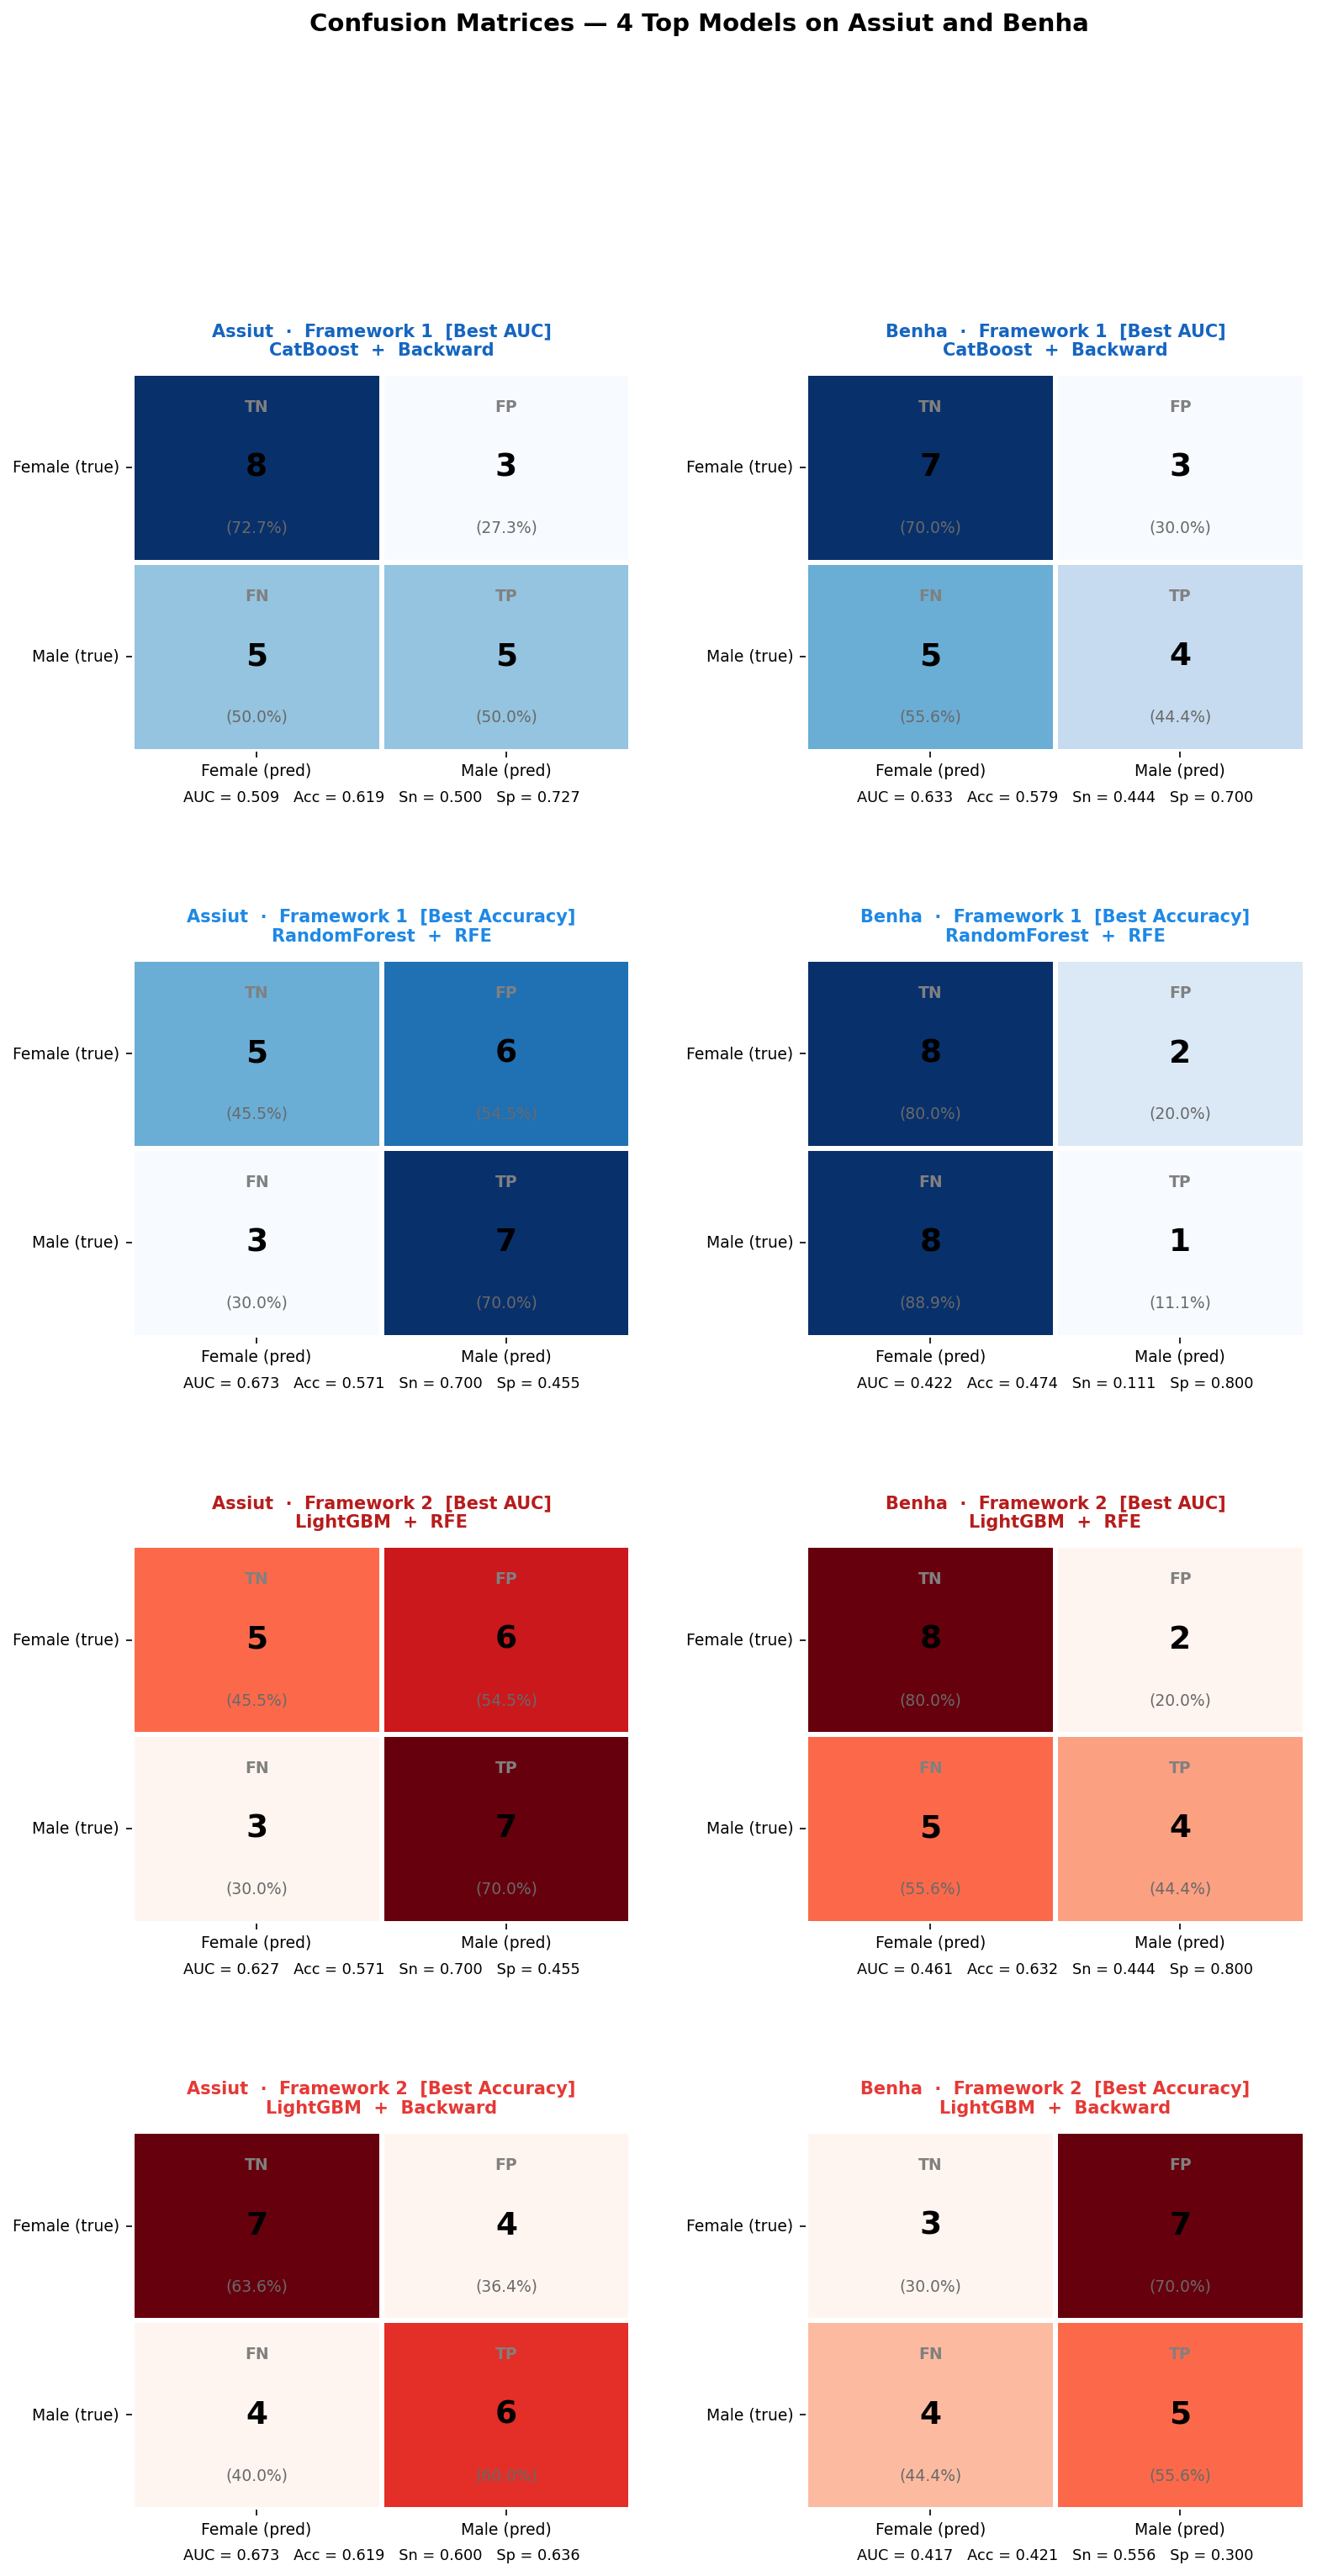

✅  fig_city_confusion_matrices.png saved

── Performance Summary ──
City      Framework       Rank            Model                AUC     Acc      Sn      Sp
──────────────────────────────────────────────────────────────────────────────────────────
Assiut    Framework 1     Best AUC        CatBoost           0.509   0.619   0.500   0.727
Assiut    Framework 1     Best Accuracy   RandomForest       0.673   0.571   0.700   0.455
Assiut    Framework 2     Best AUC        LightGBM           0.627   0.571   0.700   0.455
Assiut    Framework 2     Best Accuracy   LightGBM           0.673   0.619   0.600   0.636
Benha     Framework 1     Best AUC        CatBoost           0.633   0.579   0.444   0.700
Benha     Framework 1     Best Accuracy   RandomForest       0.422   0.474   0.111   0.800
Benha     Framework 2     Best AUC        LightGBM           0.461   0.632   0.444   0.800
Benha     Framework 2     Best Accuracy   LightGBM           0.417   0.421   0.556   0.300


In [19]:
# ══════════════════════════════════════════════════════════════
# Figure — Confusion Matrices for Assiut & Benha (4 top models)
# Reads CITY_RESULTS computed in the previous cell
# ══════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "savefig.facecolor": "white",
    "font.family":       "DejaVu Sans",
    "figure.dpi":        150,
})

CITIES  = ["Assiut", "Benha"]
N_CITY  = len(CITIES)          # 2
N_MODEL = len(ALL_TOP4)        # 4

fig = plt.figure(figsize=(6 * N_CITY, 5.5 * N_MODEL))
outer = gridspec.GridSpec(N_MODEL, N_CITY, figure=fig, hspace=0.55, wspace=0.35)

CMAP = {"Framework 1": "Blues", "Framework 2": "Reds"}

for row_idx, (fw_label, m) in enumerate(ALL_TOP4):
    for col_idx, city in enumerate(CITIES):
        # find matching entry
        entry = next(
            e for e in CITY_RESULTS[city]
            if e["model_name"] == m["model_name"] and e["fs_name"] == m["fs_name"]
        )
        r      = entry["res"]
        cm_arr = r["cm"]
        cm_pct = cm_arr.astype(float) / cm_arr.sum(axis=1, keepdims=True)

        ax = fig.add_subplot(outer[row_idx, col_idx])

        sns.heatmap(cm_arr, annot=False,
                    cmap=CMAP.get(fw_label, "Greens"),
                    ax=ax, cbar=False,
                    linewidths=2.0, linecolor="white")

        for i in range(2):
            for j in range(2):
                label = ["TN", "FP", "FN", "TP"][i * 2 + j]
                ax.text(j + 0.5, i + 0.18, label,
                        ha="center", va="center",
                        fontsize=9, color="gray", fontweight="bold")
                ax.text(j + 0.5, i + 0.50, str(cm_arr[i, j]),
                        ha="center", va="center",
                        fontsize=18, color="black", fontweight="bold")
                ax.text(j + 0.5, i + 0.82, f"({cm_pct[i,j]*100:.1f}%)",
                        ha="center", va="center",
                        fontsize=9, color="dimgray")

        ax.set_xticks([0.5, 1.5])
        ax.set_xticklabels(["Female (pred)", "Male (pred)"], fontsize=9)
        ax.set_yticks([0.5, 1.5])
        ax.set_yticklabels(["Female (true)", "Male (true)"],
                           fontsize=9, rotation=0)

        metric_line = (f"AUC = {r['test_auc']:.3f}   "
                       f"Acc = {r['test_accuracy']:.3f}   "
                       f"Sn = {r['test_sensitivity']:.3f}   "
                       f"Sp = {r['test_specificity']:.3f}")
        ax.set_xlabel(metric_line, fontsize=8.5, labelpad=6)

        title = (f"{city}  ·  {fw_label}  [{m['rank']}]\n"
                 f"{m['model_name']}  +  {m['fs_name']}")
        ax.set_title(title, fontsize=10, color=m["color"],
                     fontweight="bold", pad=10)

plt.suptitle(
    "Confusion Matrices — 4 Top Models on Assiut and Benha",
    fontsize=14, fontweight="bold", y=1.01
)

plt.savefig("figures/fig_city_confusion_matrices.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("✅  fig_city_confusion_matrices.png saved")

# ── Quick summary table ──
print("\n── Performance Summary ──")
print(f"{'City':<8}  {'Framework':<14}  {'Rank':<14}  {'Model':<16}  {'AUC':>6}  {'Acc':>6}  {'Sn':>6}  {'Sp':>6}")
print("─" * 90)
for city in CITIES:
    for e in CITY_RESULTS[city]:
        r = e["res"]
        print(f"{city:<8}  {e['fw_label']:<14}  {e['rank']:<14}  "
              f"{e['model_name']:<16}  "
              f"{r['test_auc']:>6.3f}  {r['test_accuracy']:>6.3f}  "
              f"{r['test_sensitivity']:>6.3f}  {r['test_specificity']:>6.3f}")

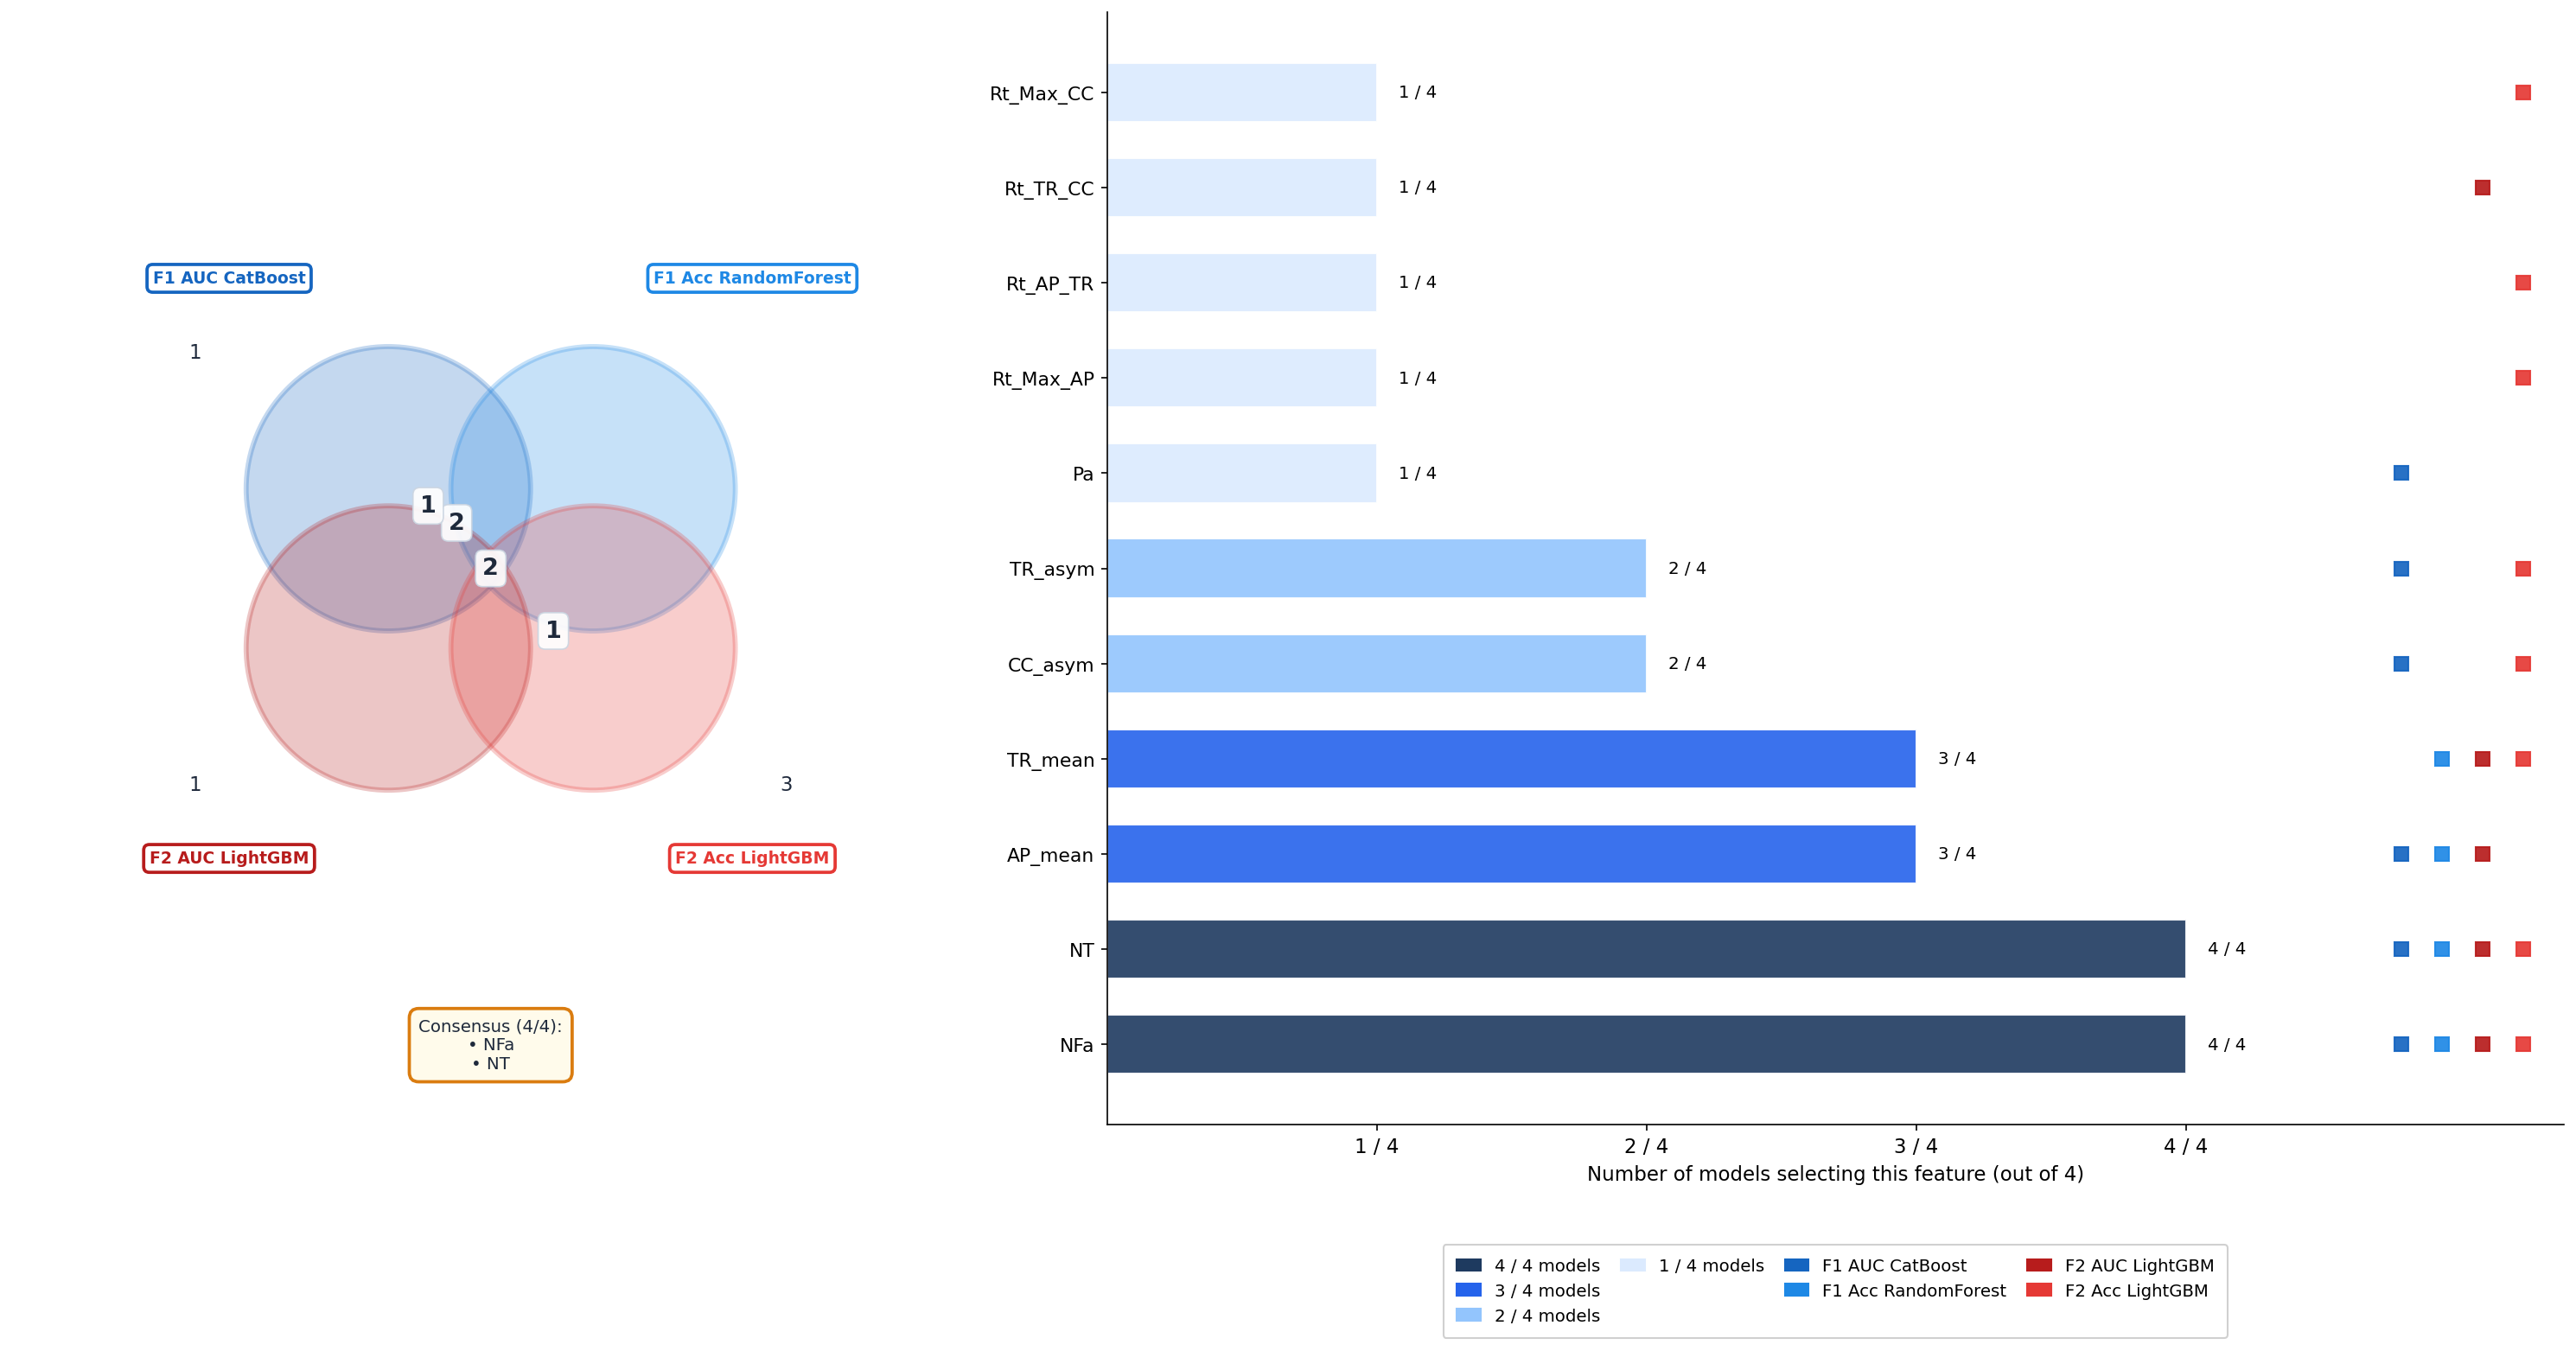

✅  fig_feature_frequency.png saved


In [20]:
# ══════════════════════════════════════════════════════════════
# Feature Overlap Venn + Selection Frequency Bar
# Reads feature_importance_top4.xlsx — fully standalone
# ══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "savefig.facecolor": "white",
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        150,
})

# ── Read Excel ──
df = pd.read_excel("results/feature_importance_top4.xlsx", sheet_name="Feature Importance")

score_cols = [c for c in df.columns if c.endswith("— Score")]

def _short(col):
    col = col.replace(" — Score", "")
    col = col.replace("Framework ", "F").replace("[", "").replace("]", "")
    col = col.replace("Best AUC", "AUC").replace("Best Accuracy", "Acc")
    return col.strip()

model_labels = [_short(c) for c in score_cols]
MODEL_COLORS = ["#1565C0", "#1E88E5", "#B71C1C", "#E53935"]

# Feature sets per model
def _is_selected(val):
    if val == "" or val is None:
        return False
    if isinstance(val, float) and np.isnan(val):
        return False
    return True

sets_all = []
for col in score_cols:
    s = set(df.loc[df[col].apply(_is_selected), "Feature"].tolist())
    sets_all.append(s)

feats   = df["Feature"].tolist()
freq    = df["Models selecting (out of 4)"].tolist()
n       = len(feats)

FREQ_COLOR = {4: "#1E3A5F", 3: "#2563EB", 2: "#93C5FD", 1: "#DBEAFE"}

# ══════════════════════════════════════════════════════════════
# 4-Circle Venn function (same as main analysis)
# ══════════════════════════════════════════════════════════════
def _draw_venn4(sets_list, labels, colors, ax):
    r    = 1.25
    cx_a = np.array([-0.90,  0.90, -0.90,  0.90])
    cy_a = np.array([ 0.70,  0.70, -0.70, -0.70])

    for i in range(4):
        ax.add_patch(Circle((cx_a[i], cy_a[i]), r,
                            facecolor=colors[i], alpha=0.25,
                            edgecolor=colors[i], linewidth=2.8, zorder=i + 1))

    all_feats = sorted(set().union(*sets_list))
    regions = {}
    for feat in all_feats:
        key = tuple(1 if feat in s else 0 for s in sets_list)
        regions.setdefault(key, []).append(feat)

    TEXT_POS = {
        (1,0,0,0): (-2.6,  1.9),
        (0,1,0,0): ( 2.6,  1.9),
        (0,0,1,0): (-2.6, -1.9),
        (0,0,0,1): ( 2.6, -1.9),
        (1,1,0,0): ( 0.0,  2.1),
        (0,0,1,1): ( 0.0, -2.1),
        (1,0,1,0): (-2.2,  0.0),
        (0,1,0,1): ( 2.2,  0.0),
        (1,0,0,1): (-0.3,  0.40),
        (0,1,1,0): ( 0.3, -0.40),
        (1,1,1,0): (-0.55, 0.55),
        (1,1,0,1): ( 0.55, 0.55),
        (1,0,1,1): (-0.55,-0.55),
        (0,1,1,1): ( 0.55,-0.55),
        (1,1,1,1): ( 0.0,  0.0),
    }

    for key, region_feats in sorted(regions.items(), key=lambda x: sum(x[0])):
        if sum(key) == 0:
            continue
        pos = TEXT_POS.get(key)
        if pos is None:
            ax_v = [cx_a[i] for i in range(4) if key[i]]
            ay_v = [cy_a[i] for i in range(4) if key[i]]
            pos  = (float(np.mean(ax_v)), float(np.mean(ay_v)))

        n_act = sum(key)
        count = len(region_feats)
        fs    = 13 if n_act >= 2 else 11
        fw    = "bold" if n_act >= 2 else "normal"
        bbox_kw = (dict(boxstyle="round,pad=0.3", facecolor="white",
                        edgecolor="#CBD5E1", alpha=0.92, linewidth=0.8)
                   if n_act > 1 else None)
        ax.text(pos[0], pos[1], str(count) if count > 0 else "",
                ha="center", va="center",
                fontsize=fs, color="#1E293B", fontweight=fw,
                bbox=bbox_kw, zorder=10)

    LABEL_POS = [(-2.3, 2.55), (2.3, 2.55), (-2.3, -2.55), (2.3, -2.55)]
    for (lx, ly), lbl, col in zip(LABEL_POS, labels, colors):
        ax.text(lx, ly, lbl, ha="center", va="center",
                fontsize=9, color=col, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                          edgecolor=col, linewidth=1.8))

    ax.set_xlim(-4.2, 4.2)
    ax.set_ylim(-3.8, 3.8)
    ax.set_aspect("equal")
    ax.axis("off")

    # Consensus annotation
    consensus = sorted(regions.get((1, 1, 1, 1), []))
    if consensus:
        ann_txt   = "Consensus (4/4):\n" + "\n".join(f"• {f}" for f in consensus)
        bbox_ann  = dict(boxstyle="round,pad=0.55", facecolor="#FFFBEB",
                         edgecolor="#D97706", linewidth=1.8, alpha=0.96)
    else:
        ann_txt  = "No feature selected\nby all 4 models"
        bbox_ann = dict(boxstyle="round,pad=0.4", facecolor="#F8FAFC",
                        edgecolor="#94A3B8", linewidth=1.2, alpha=0.9)

    ax.text(0.5, -0.02, ann_txt,
            transform=ax.transAxes,
            ha="center", va="top", fontsize=9.5, color="#1E293B",
            bbox=bbox_ann)

    return regions

# ══════════════════════════════════════════════════════════════
# Figure layout
# ══════════════════════════════════════════════════════════════
fig_h = max(8, n * 0.55 + 4)
fig, (ax_v, ax_b) = plt.subplots(
    1, 2, figsize=(20, fig_h),
    gridspec_kw={"width_ratios": [1.05, 1.6]}
)

# ── Left: Venn ──
_draw_venn4(sets_all, model_labels, MODEL_COLORS, ax_v)


# ── Right: Bar chart ──
y_pos = np.arange(n)
ax_b.barh(y_pos, freq, height=0.62,
          color=[FREQ_COLOR.get(int(f), "#CCCCCC") for f in freq],
          alpha=0.90, edgecolor="white")
ax_b.set_yticks(y_pos)
ax_b.set_yticklabels(feats, fontsize=10.5)
ax_b.set_xlabel("Number of models selecting this feature (out of 4)", fontsize=11)
ax_b.set_xlim(0, 5.4)
ax_b.set_xticks([1, 2, 3, 4])
ax_b.set_xticklabels(["1 / 4", "2 / 4", "3 / 4", "4 / 4"])

for k, val in enumerate(freq):
    ax_b.text(val + 0.08, k, f"{int(val)} / 4", va="center", fontsize=9.5)

# Per-model markers
marker_x = 4.80
marker_gap = 0.15
for k, feat in enumerate(feats):
    row = df[df["Feature"] == feat].iloc[0]
    for j, col in enumerate(score_cols):
        if _is_selected(row[col]):
            ax_b.plot(marker_x + j * marker_gap, k,
                      "s", color=MODEL_COLORS[j], markersize=8,
                      alpha=0.92, zorder=5)

# ── Legends BELOW the bar chart (outside axes) ──
freq_patches = [
    mpatches.Patch(color=FREQ_COLOR[i], label=f"{i} / 4 models")
    for i in sorted({int(f) for f in freq}, reverse=True)
    if i in FREQ_COLOR
]
marker_patches = [
    mpatches.Patch(color=MODEL_COLORS[j], label=model_labels[j])
    for j in range(len(model_labels))
]

all_handles = freq_patches + [mpatches.Patch(visible=False, label="")] + marker_patches
all_labels  = ([h.get_label() for h in freq_patches] +
               [""] +
               [h.get_label() for h in marker_patches])

ax_b.legend(
    handles=all_handles,
    labels=all_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),   # below the axes
    ncol=4,
    fontsize=9.5,
    framealpha=0.92,
    columnspacing=1.2,
    handlelength=1.4,
    borderpad=0.8,
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.13)   # make room for legend below
plt.savefig("figures/fig_feature_frequency.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅  fig_feature_frequency.png saved")